In [1]:
# =========================
# 1. IMPORTS & SETTINGS
# =========================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
# =========================
# 2. PATHS
# =========================


TRAIN_IDX_PATH = "Data/train_idx.txt"
VAL_IDX_PATH   = "Data/val_idx.txt"
TEST_IDX_PATH  = "Data/test_idx.txt"

print(TRAIN_IDX_PATH)
print(VAL_IDX_PATH)
print(TEST_IDX_PATH)

/Users/aleksandrfen/Учебные материалы/02_4 курс_2 семестр/NLP/ДЗ/Data/train_idx.txt
/Users/aleksandrfen/Учебные материалы/02_4 курс_2 семестр/NLP/ДЗ/Data/val_idx.txt
/Users/aleksandrfen/Учебные материалы/02_4 курс_2 семестр/NLP/ДЗ/Data/test_idx.txt


In [5]:
# =========================
# 3. LOAD FIXED SPLIT INDICES
# =========================

def read_idx(path):
    with open(path, "r", encoding="utf-8") as f:
        idx = [int(line.strip()) for line in f if line.strip()]
    return idx

train_idx = read_idx(TRAIN_IDX_PATH)
val_idx   = read_idx(VAL_IDX_PATH)
test_idx  = read_idx(TEST_IDX_PATH)

print(f"train_idx: {len(train_idx):,}")
print(f"val_idx:   {len(val_idx):,}")
print(f"test_idx:  {len(test_idx):,}")
print(f"total:     {len(train_idx) + len(val_idx) + len(test_idx):,}")

train_idx: 49,412
val_idx:   6,176
test_idx:  6,177
total:     61,765


In [6]:
# =========================
# 4. LOAD DATASET
# =========================

ds = load_dataset("Tobi-Bueck/customer-support-tickets")
ds

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})

In [7]:
# =========================
# 5. TO PANDAS
# =========================

df = ds["train"].to_pandas().copy()

print(df.shape)
display(df.head())
print(df.columns.tolist())

(61765, 16)


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroffenen Geräte sowie der ergriffenen ersten Maßnahmen. Wir erkennen die Dringlichke...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, and our technical team is actively working to resolve the issue. In the meantime...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit. Compatibility details can differ depending on the specific item; please let us ...",Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...","We appreciate you reaching out with your billing questions. The billing period generally begins on the first day of the month and concludes on the last day, with payments due by the 10th of the fo...",Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the specific needs of marketing agencies. Our company is consider...","Thank you for your inquiry. Our product supports integration with major CRM, email marketing, and analytics platforms through APIs and customization options. Please specify the tools you are using...",Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


In [8]:
# =========================
# 6. BASIC SPLIT CHECK
# =========================

print("Max train idx:", max(train_idx))
print("Max val idx:  ", max(val_idx))
print("Max test idx: ", max(test_idx))
print("Dataset size: ", len(df))

Max train idx: 61764
Max val idx:   61751
Max test idx:  61753
Dataset size:  61765


In [9]:
# =========================
# 7. APPLY FIXED SPLIT
# =========================

train_df = df.iloc[train_idx].copy().reset_index(drop=True)
val_df   = df.iloc[val_idx].copy().reset_index(drop=True)
test_df  = df.iloc[test_idx].copy().reset_index(drop=True)

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

train: (49412, 16)
val:   (6176, 16)
test:  (6177, 16)


In [10]:
# =========================
# 8. BASIC PREPROCESSING
# =========================

def prepare_dataframe(dataframe):
    df_ = dataframe.copy()
    
    df_["subject"] = df_["subject"].fillna("").astype(str)
    df_["body"] = df_["body"].fillna("").astype(str)
    df_["type"] = df_["type"].fillna("Unknown").astype(str)
    
    # На всякий случай приведение целевых колонок к строкам
    df_["queue"] = df_["queue"].astype(str)
    df_["priority"] = df_["priority"].astype(str)
    df_["type"] = df_["type"].astype(str)
    
    # Общий текст для модели
    df_["text"] = (df_["subject"].str.strip() + "\n\n" + df_["body"].str.strip()).str.strip()
    
    return df_

train_df = prepare_dataframe(train_df)
val_df   = prepare_dataframe(val_df)
test_df  = prepare_dataframe(test_df)

In [11]:
# =========================
# 9. MISSING VALUES CHECK
# =========================

def missing_report(dataframe, name):
    report = dataframe.isna().mean().sort_values(ascending=False).to_frame("missing_share")
    print(f"\n{name}")
    display(report[report["missing_share"] > 0])

missing_report(train_df, "TRAIN")
missing_report(val_df, "VAL")
missing_report(test_df, "TEST")


TRAIN


,missing_share
tag_8,0.959909
tag_7,0.903728
tag_6,0.785882
tag_5,0.552376
version,0.536064
tag_4,0.287380
tag_3,0.216344
tag_2,0.213612
answer,0.212884
tag_1,0.212661



VAL


,missing_share
tag_8,0.960006
tag_7,0.903174
tag_6,0.787079
tag_5,0.556995
version,0.547118
tag_4,0.294203
tag_3,0.227170
tag_2,0.224093
tag_1,0.223446
answer,0.223446



TEST


,missing_share
tag_8,0.960499
tag_7,0.900761
tag_6,0.784685
tag_5,0.549620
version,0.536021
tag_4,0.284604
tag_3,0.213048
tag_2,0.210134
tag_1,0.208839
answer,0.208839


In [12]:
# =========================
# 10. TARGET OVERVIEW
# =========================

for col in ["queue", "priority", "type"]:
    print(f"\n=== {col.upper()} ===")
    print("train nunique:", train_df[col].nunique())
    print("val nunique:  ", val_df[col].nunique())
    print("test nunique: ", test_df[col].nunique())
    print("\nTrain distribution:")
    display(train_df[col].value_counts().head(10))


=== QUEUE ===
train nunique: 52
val nunique:   52
test nunique:  52

Train distribution:


queue
Technical Support                  11354
Product Support                     7139
Customer Service                    5905
IT Support                          4673
Billing and Payments                3853
Returns and Exchanges               1956
Service Outages and Maintenance     1534
Sales and Pre-Sales                 1228
Human Resources                      730
General Inquiry                      532
Name: count, dtype: int64


=== PRIORITY ===
train nunique: 5
val nunique:   5
test nunique:  5

Train distribution:


priority
medium      18629
high        17546
low         10280
critical     1516
very_low     1441
Name: count, dtype: int64


=== TYPE ===
train nunique: 5
val nunique:   5
test nunique:  5

Train distribution:


type
Incident    15632
Request     11165
Unknown     10508
Problem      8103
Change       4004
Name: count, dtype: int64

In [13]:
# =========================
# 11. EMPTY TEXT CHECK
# =========================

for name, data in [("train", train_df), ("val", val_df), ("test", test_df)]:
    empty_mask = data["text"].str.len() == 0
    print(f"{name}: empty texts = {empty_mask.sum()} / {len(data)}")

train: empty texts = 0 / 49412
val: empty texts = 0 / 6176
test: empty texts = 0 / 6177


In [14]:
# =========================
# 12. TEXT LENGTH FEATURES
# =========================

def add_text_features(dataframe):
    df_ = dataframe.copy()
    df_["subject_len_chars"] = df_["subject"].str.len()
    df_["body_len_chars"] = df_["body"].str.len()
    df_["text_len_chars"] = df_["text"].str.len()
    
    df_["subject_len_words"] = df_["subject"].str.split().apply(len)
    df_["body_len_words"] = df_["body"].str.split().apply(len)
    df_["text_len_words"] = df_["text"].str.split().apply(len)
    return df_

train_df = add_text_features(train_df)
val_df   = add_text_features(val_df)
test_df  = add_text_features(test_df)

In [15]:
# =========================
# 13. TEXT LENGTH SUMMARY
# =========================

length_cols = [
    "subject_len_chars", "body_len_chars", "text_len_chars",
    "subject_len_words", "body_len_words", "text_len_words"
]

display(train_df[length_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
subject_len_chars,49412.0,43.347648,23.211045,0.0,31.0,43.0,56.0,675.0
body_len_chars,49412.0,419.406986,223.607335,0.0,233.0,415.0,587.0,2259.0
text_len_chars,49412.0,464.579981,226.859795,4.0,279.0,460.0,634.0,2285.0
subject_len_words,49412.0,5.067696,2.765279,0.0,4.0,5.0,7.0,77.0
body_len_words,49412.0,57.377742,30.999331,0.0,31.0,57.0,82.0,281.0
text_len_words,49412.0,62.445438,31.205693,1.0,37.0,62.0,87.0,283.0


In [16]:
# =========================
# 14. QUEUE DISTRIBUTION
# =========================

queue_counts = train_df["queue"].value_counts()

print("Number of queue classes in train:", train_df["queue"].nunique())
print("Top-10 most frequent queues:")
display(queue_counts.head(10).to_frame("count"))

print("Top-10 rarest queues:")
display(queue_counts.tail(10).to_frame("count"))

Number of queue classes in train: 52
Top-10 most frequent queues:


,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


Top-10 rarest queues:


,count
queue,
Food & Drink/Restaurants,232
Books & Literature/Fiction,232
Shopping/Retail Stores,226
People & Society/Culture & Society,220
IT & Technology/Hardware Support,219
Home & Garden/Landscaping,217
Arts & Entertainment/Movies,207
IT & Technology/Software Development,206
Sports,190


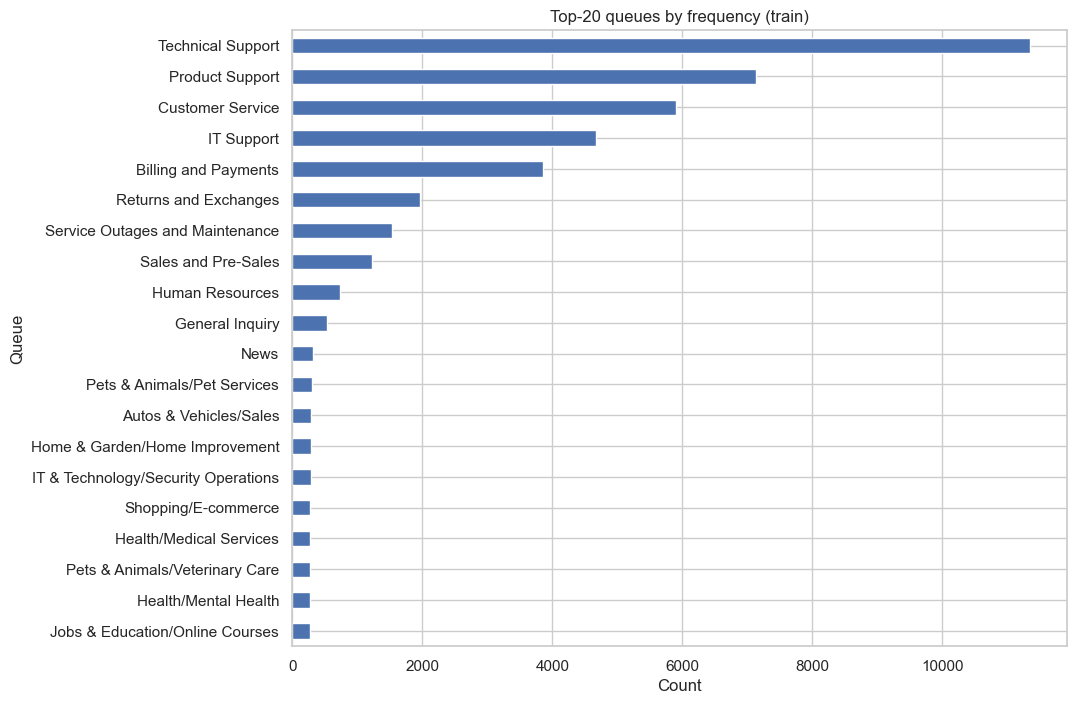

In [17]:
# =========================
# 15. QUEUE DISTRIBUTION PLOT
# =========================

top_n = 20
plot_df = queue_counts.head(top_n).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plot_df.plot(kind="barh")
plt.title(f"Top-{top_n} queues by frequency (train)")
plt.xlabel("Count")
plt.ylabel("Queue")
plt.show()

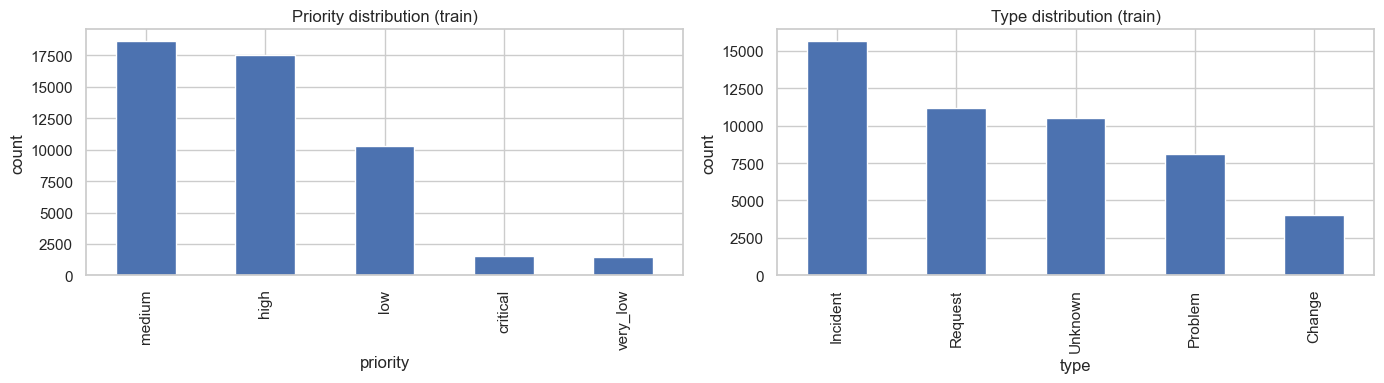

In [18]:
# =========================
# 16. PRIORITY / TYPE DISTRIBUTIONS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_df["priority"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Priority distribution (train)")
axes[0].set_xlabel("priority")
axes[0].set_ylabel("count")

train_df["type"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Type distribution (train)")
axes[1].set_xlabel("type")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

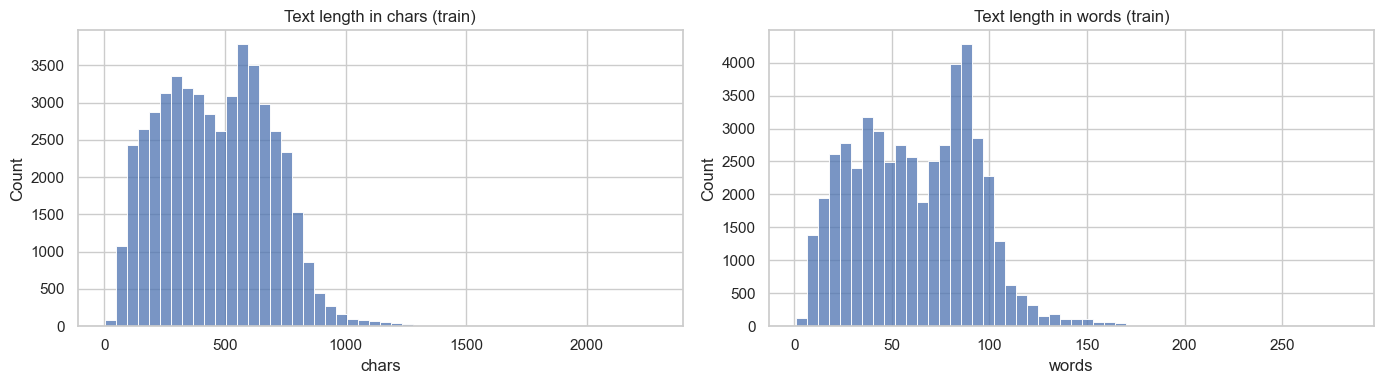

In [19]:
# =========================
# 17. TEXT LENGTH DISTRIBUTIONS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df["text_len_chars"], bins=50, ax=axes[0])
axes[0].set_title("Text length in chars (train)")
axes[0].set_xlabel("chars")

sns.histplot(train_df["text_len_words"], bins=50, ax=axes[1])
axes[1].set_title("Text length in words (train)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.show()

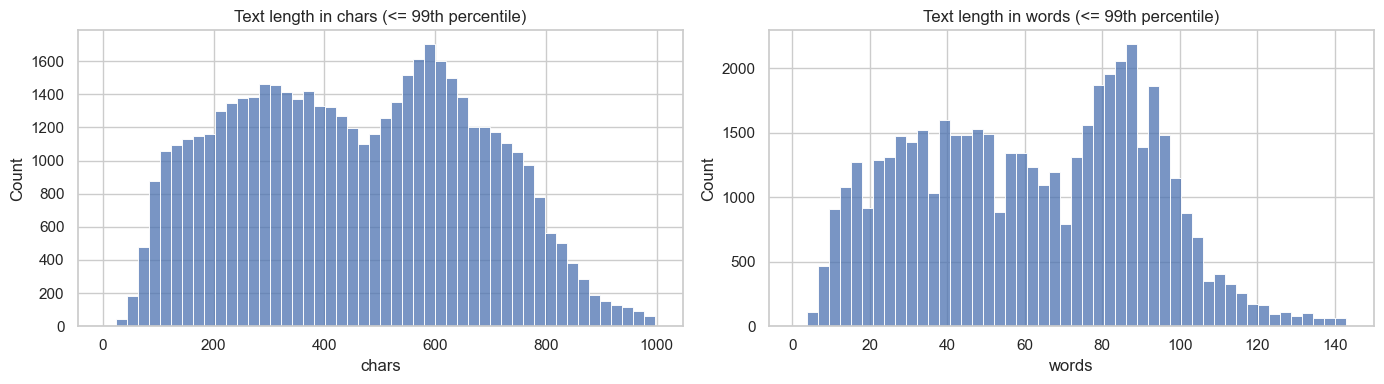

In [20]:
# =========================
# 18. TEXT LENGTH DISTRIBUTIONS (CLIPPED)
# =========================

char_q = train_df["text_len_chars"].quantile(0.99)
word_q = train_df["text_len_words"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(train_df.loc[train_df["text_len_chars"] <= char_q, "text_len_chars"], bins=50, ax=axes[0])
axes[0].set_title("Text length in chars (<= 99th percentile)")
axes[0].set_xlabel("chars")

sns.histplot(train_df.loc[train_df["text_len_words"] <= word_q, "text_len_words"], bins=50, ax=axes[1])
axes[1].set_title("Text length in words (<= 99th percentile)")
axes[1].set_xlabel("words")

plt.tight_layout()
plt.show()

Train language distribution:


,count
language,
de,26799
en,22613


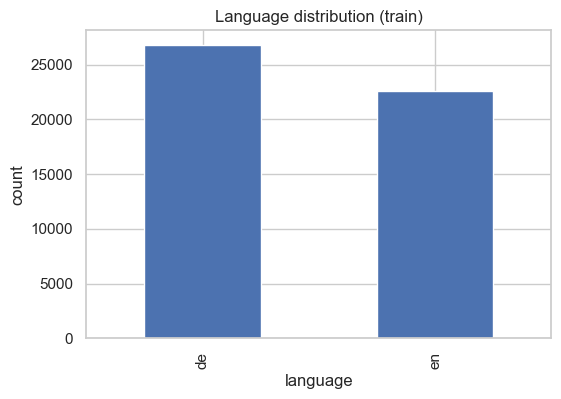

In [21]:
# =========================
# 19. LANGUAGE DISTRIBUTION
# =========================

if "language" in train_df.columns:
    print("Train language distribution:")
    display(train_df["language"].value_counts(dropna=False).to_frame("count"))
    
    plt.figure(figsize=(6, 4))
    train_df["language"].value_counts(dropna=False).plot(kind="bar")
    plt.title("Language distribution (train)")
    plt.xlabel("language")
    plt.ylabel("count")
    plt.show()

## TF-IDF + LOGISTIC REGRESSION

In [26]:
# =========================
# BASELINE 1: TF-IDF + LOGISTIC REGRESSION (QUEUE)
# =========================

X_train_text = train_df["text"].values
X_val_text   = val_df["text"].values
X_test_text  = test_df["text"].values

y_train_queue = train_df["queue"].values
y_val_queue   = val_df["queue"].values
y_test_queue  = test_df["queue"].values

print("Train size:", len(X_train_text))
print("Val size:  ", len(X_val_text))
print("Test size: ", len(X_test_text))

Train size: 49412
Val size:   6176
Test size:  6177


In [27]:
# =========================
# TF-IDF + LR PIPELINE
# =========================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_lr_queue = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.98,
            ngram_range=(1, 2),
            max_features=200_000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [28]:
# =========================
# TRAIN MODEL
# =========================

tfidf_lr_queue.fit(X_train_text, y_train_queue)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.98, max_features=200000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, random_state=42))])

In [29]:
# =========================
# PREDICTIONS
# =========================

val_pred_queue_lr = tfidf_lr_queue.predict(X_val_text)
test_pred_queue_lr = tfidf_lr_queue.predict(X_test_text)

In [31]:
# =========================
# METRICS HELPERS
# =========================

from sklearn.metrics import accuracy_score, f1_score

def compute_classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }
# =========================
# EVALUATION
# =========================

val_metrics_queue_lr = compute_classification_metrics(y_val_queue, val_pred_queue_lr)
test_metrics_queue_lr = compute_classification_metrics(y_test_queue, test_pred_queue_lr)

print("TF-IDF + LogisticRegression | QUEUE")
print("-" * 40)
print(f"Validation Accuracy : {val_metrics_queue_lr['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_lr['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_lr['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_lr['macro_f1']:.4f}")

TF-IDF + LogisticRegression | QUEUE
----------------------------------------
Validation Accuracy : 0.5112
Validation Macro-F1 : 0.8298

Test Accuracy       : 0.5166
Test Macro-F1       : 0.8192


In [32]:
# =========================
# CLASSIFICATION REPORT
# =========================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_queue,
        test_pred_queue_lr,
        zero_division=0
    )
)
report_lr_queue = pd.DataFrame(
    classification_report(
        y_test_queue,
        test_pred_queue_lr,
        zero_division=0,
        output_dict=True
    )
).T

display(report_lr_queue.head(15))

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       1.00      0.88      0.94        26
            Arts & Entertainment/Music       0.89      1.00      0.94        24
          Autos & Vehicles/Maintenance       0.85      0.88      0.87        26
                Autos & Vehicles/Sales       0.86      0.95      0.90        38
            Beauty & Fitness/Cosmetics       0.88      0.92      0.90        24
     Beauty & Fitness/Fitness Training       1.00      0.92      0.96        26
                  Billing and Payments       0.70      0.68      0.69       532
            Books & Literature/Fiction       1.00      0.86      0.92        28
        Books & Literature/Non-Fiction       0.87      0.94      0.91        36
   Business & Industrial/Manufacturing       0.97      0.97      0.97        33
                      Customer Service       0.35      0.30      0.33       766
                   Finance/Investments 

,precision,recall,f1-score,support
Arts & Entertainment/Movies,1.000000,0.884615,0.938776,26.0
Arts & Entertainment/Music,0.888889,1.000000,0.941176,24.0
Autos & Vehicles/Maintenance,0.851852,0.884615,0.867925,26.0
Autos & Vehicles/Sales,0.857143,0.947368,0.900000,38.0
Beauty & Fitness/Cosmetics,0.880000,0.916667,0.897959,24.0
Beauty & Fitness/Fitness Training,1.000000,0.923077,0.960000,26.0
Billing and Payments,0.700000,0.684211,0.692015,532.0
Books & Literature/Fiction,1.000000,0.857143,0.923077,28.0
Books & Literature/Non-Fiction,0.871795,0.944444,0.906667,36.0
Business & Industrial/Manufacturing,0.969697,0.969697,0.969697,33.0


In [33]:
# =========================
# RESULTS TABLE
# =========================

results_main = pd.DataFrame([
    {
        "method": "TF-IDF + LogisticRegression",
        "val_accuracy_queue": val_metrics_queue_lr["accuracy"],
        "val_macro_f1_queue": val_metrics_queue_lr["macro_f1"],
        "test_accuracy_queue": test_metrics_queue_lr["accuracy"],
        "test_macro_f1_queue": test_metrics_queue_lr["macro_f1"],
    }
])

display(results_main)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194


## TF-IDF + LINEARSVC

In [34]:
# =========================
# BASELINE 2: TF-IDF + LINEARSVC (QUEUE)
# =========================

from sklearn.svm import LinearSVC

tfidf_svc_queue = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.98,
            ngram_range=(1, 2),
            max_features=200_000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

In [35]:
# =========================
# TRAIN MODEL
# =========================

tfidf_svc_queue.fit(X_train_text, y_train_queue)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.98, max_features=200000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', LinearSVC(class_weight='balanced', random_state=42))])

In [36]:
# =========================
# PREDICTIONS
# =========================

val_pred_queue_svc = tfidf_svc_queue.predict(X_val_text)
test_pred_queue_svc = tfidf_svc_queue.predict(X_test_text)

In [37]:
# =========================
# EVALUATION
# =========================

val_metrics_queue_svc = compute_classification_metrics(y_val_queue, val_pred_queue_svc)
test_metrics_queue_svc = compute_classification_metrics(y_test_queue, test_pred_queue_svc)

print("TF-IDF + LinearSVC | QUEUE")
print("-" * 40)
print(f"Validation Accuracy : {val_metrics_queue_svc['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_svc['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_svc['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_svc['macro_f1']:.4f}")

TF-IDF + LinearSVC | QUEUE
----------------------------------------
Validation Accuracy : 0.6516
Validation Macro-F1 : 0.8807

Test Accuracy       : 0.6638
Test Macro-F1       : 0.8805


In [38]:
# =========================
# CLASSIFICATION REPORT
# =========================

print(
    classification_report(
        y_test_queue,
        test_pred_queue_svc,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.88      0.88      0.88        26
            Arts & Entertainment/Music       0.89      1.00      0.94        24
          Autos & Vehicles/Maintenance       1.00      0.92      0.96        26
                Autos & Vehicles/Sales       0.90      1.00      0.95        38
            Beauty & Fitness/Cosmetics       0.96      0.96      0.96        24
     Beauty & Fitness/Fitness Training       1.00      0.96      0.98        26
                  Billing and Payments       0.76      0.81      0.78       532
            Books & Literature/Fiction       0.96      0.93      0.95        28
        Books & Literature/Non-Fiction       0.97      0.97      0.97        36
   Business & Industrial/Manufacturing       0.94      1.00      0.97        33
                      Customer Service       0.57      0.51      0.54       766
                   Finance/Investments 

In [39]:
report_svc_queue = pd.DataFrame(
    classification_report(
        y_test_queue,
        test_pred_queue_svc,
        zero_division=0,
        output_dict=True
    )
).T

display(report_svc_queue.head(15))

,precision,recall,f1-score,support
Arts & Entertainment/Movies,0.884615,0.884615,0.884615,26.0
Arts & Entertainment/Music,0.888889,1.000000,0.941176,24.0
Autos & Vehicles/Maintenance,1.000000,0.923077,0.960000,26.0
Autos & Vehicles/Sales,0.904762,1.000000,0.950000,38.0
Beauty & Fitness/Cosmetics,0.958333,0.958333,0.958333,24.0
Beauty & Fitness/Fitness Training,1.000000,0.961538,0.980392,26.0
Billing and Payments,0.756567,0.812030,0.783318,532.0
Books & Literature/Fiction,0.962963,0.928571,0.945455,28.0
Books & Literature/Non-Fiction,0.972222,0.972222,0.972222,36.0
Business & Industrial/Manufacturing,0.942857,1.000000,0.970588,33.0


In [40]:
# =========================
# UPDATE RESULTS TABLE
# =========================

results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "TF-IDF + LinearSVC",
            "val_accuracy_queue": val_metrics_queue_svc["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_svc["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_svc["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_svc["macro_f1"],
        }
    ])
], ignore_index=True)

display(results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True))

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194


,test_accuracy_queue,test_macro_f1_queue
method,,
TF-IDF + LogisticRegression,0.516594,0.819194
TF-IDF + LinearSVC,0.663753,0.880546


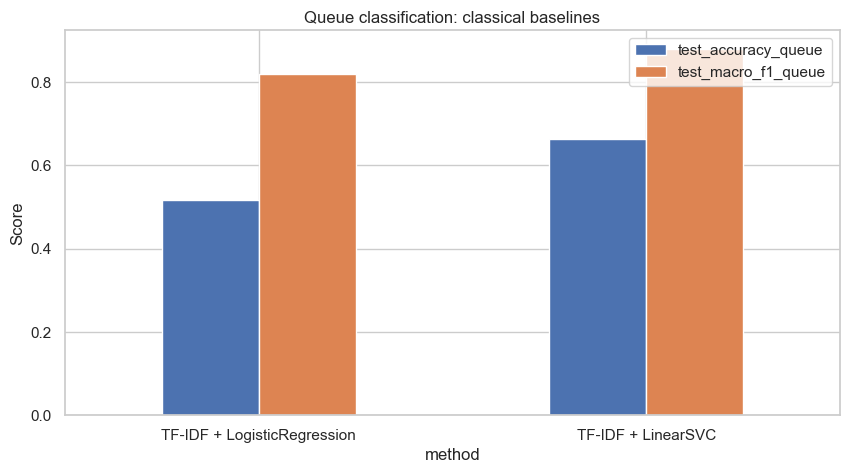

In [41]:
# =========================
# COMPARE LR VS LINEARSVC
# =========================

plot_df = results_main.set_index("method")[["test_accuracy_queue", "test_macro_f1_queue"]]
display(plot_df)

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Queue classification: classical baselines")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## CountVectorizer + LogisticRegression

In [48]:
# =========================
# BASELINE 0: COUNTVECTORIZER + LOGISTIC REGRESSION (QUEUE)
# =========================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

In [49]:
count_lr_queue = Pipeline([
    (
        "count",
        CountVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.98,
            ngram_range=(1, 2),
            max_features=200_000
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    )
])

In [50]:
count_lr_queue.fit(X_train_text, y_train_queue)

Pipeline(steps=[('count',
                 CountVectorizer(max_df=0.98, max_features=200000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, random_state=42))])

In [51]:
val_pred_queue_count_lr = count_lr_queue.predict(X_val_text)
test_pred_queue_count_lr = count_lr_queue.predict(X_test_text)

In [52]:
val_metrics_queue_count_lr = compute_classification_metrics(
    y_val_queue, val_pred_queue_count_lr
)
test_metrics_queue_count_lr = compute_classification_metrics(
    y_test_queue, test_pred_queue_count_lr
)

print("CountVectorizer + LogisticRegression | QUEUE")
print("-" * 45)
print(f"Validation Accuracy : {val_metrics_queue_count_lr['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_count_lr['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_count_lr['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_count_lr['macro_f1']:.4f}")

CountVectorizer + LogisticRegression | QUEUE
---------------------------------------------
Validation Accuracy : 0.6399
Validation Macro-F1 : 0.8578

Test Accuracy       : 0.6445
Test Macro-F1       : 0.8534


In [53]:
results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "CountVectorizer + LogisticRegression",
            "val_accuracy_queue": val_metrics_queue_count_lr["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_count_lr["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_count_lr["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_count_lr["macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194


,test_accuracy_queue,test_macro_f1_queue
method,,
TF-IDF + LogisticRegression,0.516594,0.819194
TF-IDF + LinearSVC,0.663753,0.880546
CountVectorizer + LogisticRegression,0.644488,0.853407


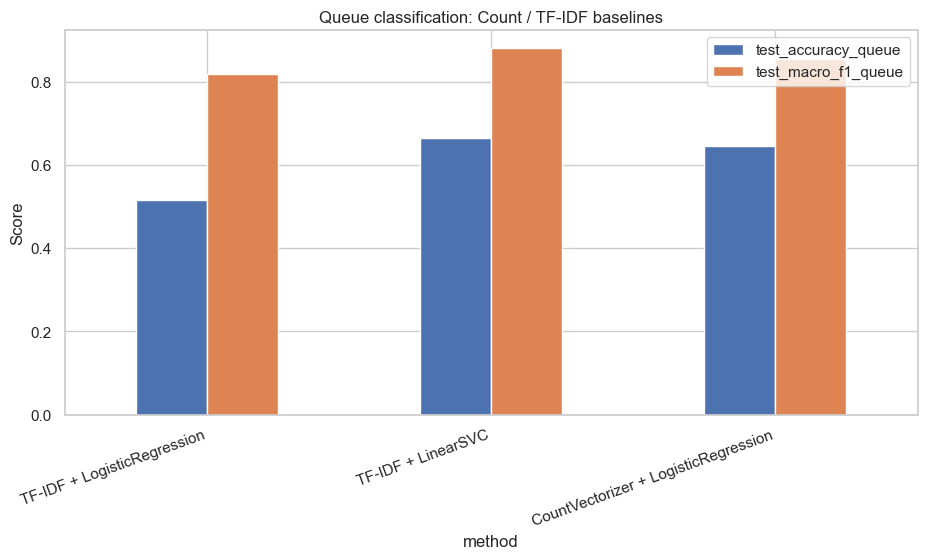

In [54]:
plot_df = results_main.set_index("method")[["test_accuracy_queue", "test_macro_f1_queue"]]

display(plot_df)

plot_df.plot(kind="bar", figsize=(11, 5))
plt.title("Queue classification: Count / TF-IDF baselines")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.show()

## Word2Vec

In [55]:
# =========================
# WORD2VEC PIPELINE
# =========================

from gensim.utils import simple_preprocess
from gensim.models import Word2Vec, Phrases
from gensim.models.phrases import Phraser

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from tqdm.auto import tqdm

In [56]:
# =========================
# TOKENIZATION
# =========================

def tokenize_for_w2v(text):
    return simple_preprocess(str(text), deacc=True, min_len=2, max_len=30)

train_tokens = [tokenize_for_w2v(text) for text in tqdm(X_train_text, desc="Tokenizing train")]
val_tokens   = [tokenize_for_w2v(text) for text in tqdm(X_val_text, desc="Tokenizing val")]
test_tokens  = [tokenize_for_w2v(text) for text in tqdm(X_test_text, desc="Tokenizing test")]

print(train_tokens[0][:30])
print(len(train_tokens), len(val_tokens), len(test_tokens))

Tokenizing train:   0%|          | 0/49412 [00:00<?, ?it/s]

Tokenizing val:   0%|          | 0/6176 [00:00<?, ?it/s]

Tokenizing test:   0%|          | 0/6177 [00:00<?, ?it/s]

['wesentlicher', 'sicherheitsvorfall', 'sehr', 'geehrtes', 'support', 'team', 'nich', 'mochte', 'einen', 'gravierenden', 'sicherheitsvorfall', 'melden', 'der', 'gegenwartig', 'mehrere', 'komponenten', 'unserer', 'infrastruktur', 'betrifft', 'betroffene', 'gerate', 'umfassen', 'projektoren', 'bildschirme', 'und', 'speicherlosungen', 'auf', 'cloud', 'plattformen', 'der']
49412 6176 6177


In [57]:
# =========================
# BIGRAMS
# =========================

phrases = Phrases(
    train_tokens,
    min_count=5,
    threshold=10.0,
    delimiter="_"
)

bigram = Phraser(phrases)

train_tokens_bg = [bigram[toks] for toks in tqdm(train_tokens, desc="Applying bigrams to train")]
val_tokens_bg   = [bigram[toks] for toks in tqdm(val_tokens, desc="Applying bigrams to val")]
test_tokens_bg  = [bigram[toks] for toks in tqdm(test_tokens, desc="Applying bigrams to test")]

print(train_tokens_bg[0][:30])

Applying bigrams to train:   0%|          | 0/49412 [00:00<?, ?it/s]

Applying bigrams to val:   0%|          | 0/6176 [00:00<?, ?it/s]

Applying bigrams to test:   0%|          | 0/6177 [00:00<?, ?it/s]

['wesentlicher', 'sicherheitsvorfall', 'sehr_geehrtes', 'support_team', 'nich', 'mochte', 'einen', 'gravierenden', 'sicherheitsvorfall', 'melden', 'der', 'gegenwartig', 'mehrere', 'komponenten', 'unserer', 'infrastruktur', 'betrifft', 'betroffene_gerate', 'umfassen', 'projektoren', 'bildschirme', 'und', 'speicherlosungen', 'auf', 'cloud', 'plattformen', 'der', 'grund', 'fur', 'die']


In [58]:
# =========================
# TRAIN WORD2VEC
# =========================

w2v_model = Word2Vec(
    sentences=train_tokens_bg,
    vector_size=300,
    window=8,
    min_count=3,
    workers=4,
    sg=1,              # skip-gram
    negative=10,
    sample=1e-5,
    epochs=15,
    seed=SEED
)

print("Word2Vec vocabulary size:", len(w2v_model.wv))
print("Vector size:", w2v_model.wv.vector_size)

Word2Vec vocabulary size: 26327
Vector size: 300


In [59]:
# =========================
# TF-IDF WEIGHTS OVER TOKENS
# =========================

tfidf_for_w2v = TfidfVectorizer(
    analyzer=lambda x: x,
    lowercase=False,
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

X_train_tfidf_tok = tfidf_for_w2v.fit_transform(train_tokens_bg)
X_val_tfidf_tok   = tfidf_for_w2v.transform(val_tokens_bg)
X_test_tfidf_tok  = tfidf_for_w2v.transform(test_tokens_bg)

tfidf_vocab = tfidf_for_w2v.vocabulary_

print(X_train_tfidf_tok.shape, X_val_tfidf_tok.shape, X_test_tfidf_tok.shape)
print("TF-IDF vocab size:", len(tfidf_vocab))

(49412, 32042) (6176, 32042) (6177, 32042)
TF-IDF vocab size: 32042


In [60]:
# =========================
# TF-IDF WEIGHTED DOC VECTORS
# =========================

def build_weighted_doc_vectors(token_lists, tfidf_matrix, tfidf_vocab, w2v_model):
    dim = w2v_model.wv.vector_size
    doc_vectors = np.zeros((len(token_lists), dim), dtype=np.float32)

    for i, tokens in enumerate(tqdm(token_lists, desc="Building doc vectors")):
        row = tfidf_matrix.getrow(i)
        weights_map = {term_idx: weight for term_idx, weight in zip(row.indices, row.data)}

        weighted_vectors = []
        weighted_sum = 0.0

        for token in tokens:
            if token in w2v_model.wv and token in tfidf_vocab:
                term_idx = tfidf_vocab[token]
                weight = weights_map.get(term_idx, 0.0)
                if weight > 0:
                    weighted_vectors.append(w2v_model.wv[token] * weight)
                    weighted_sum += weight

        if weighted_vectors and weighted_sum > 0:
            doc_vectors[i] = np.sum(weighted_vectors, axis=0) / weighted_sum
        else:
            doc_vectors[i] = np.zeros(dim, dtype=np.float32)

    return doc_vectors

In [61]:
# =========================
# BUILD DOCUMENT MATRICES
# =========================

X_train_w2v = build_weighted_doc_vectors(
    train_tokens_bg, X_train_tfidf_tok, tfidf_vocab, w2v_model
)

X_val_w2v = build_weighted_doc_vectors(
    val_tokens_bg, X_val_tfidf_tok, tfidf_vocab, w2v_model
)

X_test_w2v = build_weighted_doc_vectors(
    test_tokens_bg, X_test_tfidf_tok, tfidf_vocab, w2v_model
)

print("X_train_w2v:", X_train_w2v.shape)
print("X_val_w2v:  ", X_val_w2v.shape)
print("X_test_w2v: ", X_test_w2v.shape)

Building doc vectors:   0%|          | 0/49412 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6176 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6177 [00:00<?, ?it/s]

X_train_w2v: (49412, 300)
X_val_w2v:   (6176, 300)
X_test_w2v:  (6177, 300)


In [62]:
# =========================
# SCALING
# =========================

from sklearn.preprocessing import StandardScaler

scaler_w2v = StandardScaler()
X_train_w2v_scaled = scaler_w2v.fit_transform(X_train_w2v)
X_val_w2v_scaled   = scaler_w2v.transform(X_val_w2v)
X_test_w2v_scaled  = scaler_w2v.transform(X_test_w2v)

In [63]:
# =========================
# CLASSIFIER: LINEARSVC
# =========================

w2v_svc_queue = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED
)

w2v_svc_queue.fit(X_train_w2v_scaled, y_train_queue)

LinearSVC(class_weight='balanced', random_state=42)

In [64]:
# =========================
# EVALUATION
# =========================

val_pred_queue_w2v = w2v_svc_queue.predict(X_val_w2v_scaled)
test_pred_queue_w2v = w2v_svc_queue.predict(X_test_w2v_scaled)

val_metrics_queue_w2v = compute_classification_metrics(y_val_queue, val_pred_queue_w2v)
test_metrics_queue_w2v = compute_classification_metrics(y_test_queue, test_pred_queue_w2v)

print("Word2Vec(tf-idf weighted) + LinearSVC | QUEUE")
print("-" * 55)
print(f"Validation Accuracy : {val_metrics_queue_w2v['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_w2v['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_w2v['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_w2v['macro_f1']:.4f}")

Word2Vec(tf-idf weighted) + LinearSVC | QUEUE
-------------------------------------------------------
Validation Accuracy : 0.3888
Validation Macro-F1 : 0.6706

Test Accuracy       : 0.3895
Test Macro-F1       : 0.6549


In [65]:
# =========================
# UPDATE RESULTS TABLE
# =========================

results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "Word2Vec(tfidf-weighted) + LinearSVC",
            "val_accuracy_queue": val_metrics_queue_w2v["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_w2v["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_w2v["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_w2v["macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
3,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855


,test_accuracy_queue,test_macro_f1_queue
method,,
TF-IDF + LogisticRegression,0.516594,0.819194
TF-IDF + LinearSVC,0.663753,0.880546
CountVectorizer + LogisticRegression,0.644488,0.853407
Word2Vec(tfidf-weighted) + LinearSVC,0.389509,0.654855


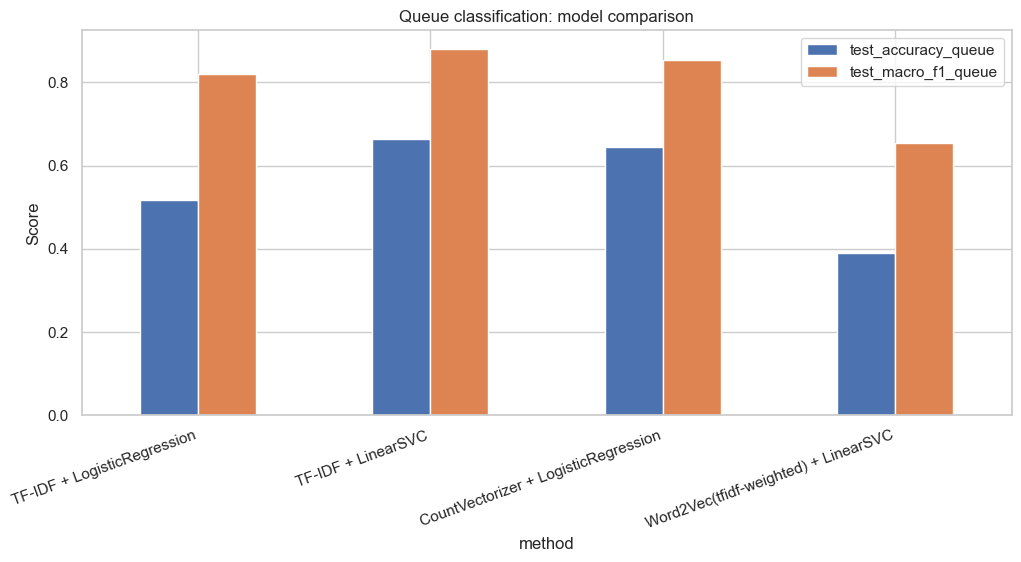

In [66]:
# =========================
# COMPARE METHODS
# =========================

plot_df = results_main.set_index("method")[["test_accuracy_queue", "test_macro_f1_queue"]]
display(plot_df)

plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Queue classification: model comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.show()

## FastText

In [67]:
# =========================
# FASTTEXT MODEL
# =========================

from gensim.models import FastText

In [68]:
# =========================
# TRAIN FASTTEXT
# =========================

fasttext_model = FastText(
    sentences=train_tokens_bg,
    vector_size=300,
    window=8,
    min_count=3,
    workers=4,
    sg=1,            # skip-gram
    negative=10,
    sample=1e-5,
    epochs=15,
    seed=SEED
)

print("FastText vocab size:", len(fasttext_model.wv))
print("Vector size:", fasttext_model.wv.vector_size)

FastText vocab size: 26327
Vector size: 300


In [69]:
X_train_ft = build_weighted_doc_vectors(
    train_tokens_bg, X_train_tfidf_tok, tfidf_vocab, fasttext_model
)

X_val_ft = build_weighted_doc_vectors(
    val_tokens_bg, X_val_tfidf_tok, tfidf_vocab, fasttext_model
)

X_test_ft = build_weighted_doc_vectors(
    test_tokens_bg, X_test_tfidf_tok, tfidf_vocab, fasttext_model
)

print("X_train_ft:", X_train_ft.shape)

Building doc vectors:   0%|          | 0/49412 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6176 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6177 [00:00<?, ?it/s]

X_train_ft: (49412, 300)


In [70]:
scaler_ft = StandardScaler()

X_train_ft_scaled = scaler_ft.fit_transform(X_train_ft)
X_val_ft_scaled   = scaler_ft.transform(X_val_ft)
X_test_ft_scaled  = scaler_ft.transform(X_test_ft)

In [71]:
fasttext_svc_queue = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED
)

fasttext_svc_queue.fit(X_train_ft_scaled, y_train_queue)

LinearSVC(class_weight='balanced', random_state=42)

In [72]:
val_pred_queue_ft = fasttext_svc_queue.predict(X_val_ft_scaled)
test_pred_queue_ft = fasttext_svc_queue.predict(X_test_ft_scaled)

val_metrics_queue_ft = compute_classification_metrics(
    y_val_queue, val_pred_queue_ft
)

test_metrics_queue_ft = compute_classification_metrics(
    y_test_queue, test_pred_queue_ft
)

print("FastText(tf-idf weighted) + LinearSVC | QUEUE")
print("-" * 55)
print(f"Validation Accuracy : {val_metrics_queue_ft['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_ft['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_ft['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_ft['macro_f1']:.4f}")

FastText(tf-idf weighted) + LinearSVC | QUEUE
-------------------------------------------------------
Validation Accuracy : 0.3970
Validation Macro-F1 : 0.6842

Test Accuracy       : 0.4017
Test Macro-F1       : 0.6807


In [73]:
results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "FastText(tfidf-weighted) + LinearSVC",
            "val_accuracy_queue": val_metrics_queue_ft["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_ft["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_ft["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_ft["macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
3,FastText(tfidf-weighted) + LinearSVC,0.397021,0.684206,0.401651,0.680731
4,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855


## Снова Word2Vec, но на кэтбусте

In [74]:
# =========================
# WORD2VEC + CATBOOST (QUEUE)
# =========================

from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import numpy as np
from tqdm.auto import tqdm

In [75]:
# =========================
# TRAIN WORD2VEC
# =========================

w2v_model = Word2Vec(
    sentences=train_tokens_bg,
    vector_size=300,
    window=8,
    min_count=3,
    workers=4,
    sg=1,             # skip-gram
    negative=10,
    sample=1e-5,
    epochs=15,
    seed=SEED
)

print("Word2Vec vocab size:", len(w2v_model.wv))
print("Vector size:", w2v_model.wv.vector_size)

Word2Vec vocab size: 26327
Vector size: 300


In [76]:
# =========================
# TF-IDF OVER TOKENS
# =========================

tfidf_for_w2v = TfidfVectorizer(
    analyzer=lambda x: x,
    lowercase=False,
    min_df=2,
    max_df=0.98,
    sublinear_tf=True
)

X_train_tfidf_tok = tfidf_for_w2v.fit_transform(train_tokens_bg)
X_val_tfidf_tok   = tfidf_for_w2v.transform(val_tokens_bg)
X_test_tfidf_tok  = tfidf_for_w2v.transform(test_tokens_bg)

tfidf_vocab = tfidf_for_w2v.vocabulary_

print("TF-IDF vocab size:", len(tfidf_vocab))

TF-IDF vocab size: 32042


In [77]:
# =========================
# BUILD TF-IDF WEIGHTED DOC VECTORS
# =========================

def build_weighted_doc_vectors(token_lists, tfidf_matrix, tfidf_vocab, w2v_model):

    dim = w2v_model.wv.vector_size
    doc_vectors = np.zeros((len(token_lists), dim), dtype=np.float32)

    for i, tokens in enumerate(tqdm(token_lists, desc="Building doc vectors")):

        row = tfidf_matrix.getrow(i)
        weights_map = {idx: val for idx, val in zip(row.indices, row.data)}

        weighted_vecs = []
        weight_sum = 0.0

        for token in tokens:

            if token in w2v_model.wv and token in tfidf_vocab:

                term_idx = tfidf_vocab[token]
                weight = weights_map.get(term_idx, 0.0)

                if weight > 0:
                    weighted_vecs.append(w2v_model.wv[token] * weight)
                    weight_sum += weight

        if weighted_vecs and weight_sum > 0:
            doc_vectors[i] = np.sum(weighted_vecs, axis=0) / weight_sum
        else:
            doc_vectors[i] = np.zeros(dim)

    return doc_vectors

In [78]:
# =========================
# BUILD MATRICES
# =========================

X_train_w2v = build_weighted_doc_vectors(
    train_tokens_bg,
    X_train_tfidf_tok,
    tfidf_vocab,
    w2v_model
)

X_val_w2v = build_weighted_doc_vectors(
    val_tokens_bg,
    X_val_tfidf_tok,
    tfidf_vocab,
    w2v_model
)

X_test_w2v = build_weighted_doc_vectors(
    test_tokens_bg,
    X_test_tfidf_tok,
    tfidf_vocab,
    w2v_model
)

print("Train shape:", X_train_w2v.shape)
print("Val shape:", X_val_w2v.shape)
print("Test shape:", X_test_w2v.shape)

Building doc vectors:   0%|          | 0/49412 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6176 [00:00<?, ?it/s]

Building doc vectors:   0%|          | 0/6177 [00:00<?, ?it/s]

Train shape: (49412, 300)
Val shape: (6176, 300)
Test shape: (6177, 300)


In [79]:
# =========================
# SCALE FEATURES
# =========================

scaler = StandardScaler()

X_train_w2v_scaled = scaler.fit_transform(X_train_w2v)
X_val_w2v_scaled   = scaler.transform(X_val_w2v)
X_test_w2v_scaled  = scaler.transform(X_test_w2v)

In [80]:
# =========================
# CATBOOST CLASSIFIER
# =========================

w2v_cat_queue = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=SEED,
    verbose=100
)

w2v_cat_queue.fit(
    X_train_w2v_scaled,
    y_train_queue,
    eval_set=(X_val_w2v_scaled, y_val_queue)
)

0:	learn: 3.6212554	test: 3.6216533	best: 3.6216533 (0)	total: 1.22s	remaining: 16m 13s
100:	learn: 1.7687218	test: 1.8619222	best: 1.8619222 (100)	total: 1m 32s	remaining: 10m 43s
200:	learn: 1.5619752	test: 1.7084871	best: 1.7084871 (200)	total: 2m 54s	remaining: 8m 39s
300:	learn: 1.4597145	test: 1.6475051	best: 1.6475051 (300)	total: 4m 14s	remaining: 7m 2s
400:	learn: 1.3749848	test: 1.6000829	best: 1.6000829 (400)	total: 5m 34s	remaining: 5m 32s
500:	learn: 1.3047217	test: 1.5638705	best: 1.5638705 (500)	total: 6m 53s	remaining: 4m 7s
600:	learn: 1.2438501	test: 1.5344447	best: 1.5344447 (600)	total: 8m 14s	remaining: 2m 43s
700:	learn: 1.1898458	test: 1.5095333	best: 1.5095333 (700)	total: 9m 35s	remaining: 1m 21s
799:	learn: 1.1396122	test: 1.4873245	best: 1.4873245 (799)	total: 10m 57s	remaining: 0us

bestTest = 1.487324484
bestIteration = 799



In [81]:
val_pred_queue_w2v_cb = w2v_cat_queue.predict(X_val_w2v_scaled)
test_pred_queue_w2v_cb = w2v_cat_queue.predict(X_test_w2v_scaled)

In [82]:
val_metrics_queue_w2v_cb = compute_classification_metrics(
    y_val_queue,
    val_pred_queue_w2v_cb
)

test_metrics_queue_w2v_cb = compute_classification_metrics(
    y_test_queue,
    test_pred_queue_w2v_cb
)

print("Word2Vec + CatBoost | QUEUE")
print("-" * 50)
print(f"Validation Accuracy : {val_metrics_queue_w2v_cb['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_w2v_cb['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_w2v_cb['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_w2v_cb['macro_f1']:.4f}")

Word2Vec + CatBoost | QUEUE
--------------------------------------------------
Validation Accuracy : 0.4998
Validation Macro-F1 : 0.6395

Test Accuracy       : 0.5095
Test Macro-F1       : 0.6449


In [83]:
results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "Word2Vec(tfidf-weighted) + CatBoost",
            "val_accuracy_queue": val_metrics_queue_w2v_cb["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_w2v_cb["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_w2v_cb["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_w2v_cb["macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
3,FastText(tfidf-weighted) + LinearSVC,0.397021,0.684206,0.401651,0.680731
4,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855
5,Word2Vec(tfidf-weighted) + CatBoost,0.499838,0.639526,0.509471,0.644927


## BERT - XLM-RoBERTa CLS embeddings + LogisticRegression

In [84]:
# =========================
# FEATURE-BASED XLM-R FOR QUEUE
# =========================

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from tqdm.auto import tqdm

In [85]:
# =========================
# DEVICE & MODEL NAME
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "xlm-roberta-base"

print("DEVICE:", DEVICE)
print("MODEL_NAME:", MODEL_NAME)

DEVICE: cpu
MODEL_NAME: xlm-roberta-base


In [86]:
# =========================
# TOKENIZER & ENCODER
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME)
encoder.to(DEVICE)
encoder.eval();

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

In [87]:
# =========================
# DATASET
# =========================

class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = list(texts)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [88]:
# =========================
# COLLATE FUNCTION
# =========================

MAX_LENGTH = 128
BATCH_SIZE = 32

def collate_batch(batch_texts):
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    return {k: v.to(DEVICE) for k, v in encoded.items()}

In [89]:
# =========================
# EXTRACT CLS EMBEDDINGS
# =========================

@torch.no_grad()
def extract_cls_embeddings(texts, batch_size=BATCH_SIZE):
    dataset = TextDataset(texts)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch
    )

    all_embeddings = []

    for batch in tqdm(loader, desc="Extracting CLS embeddings"):
        outputs = encoder(**batch)
        cls_emb = outputs.last_hidden_state[:, 0, :]   # [batch, hidden_size]
        all_embeddings.append(cls_emb.detach().cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
    return all_embeddings

In [90]:
# =========================
# EXTRACT CLS EMBEDDINGS
# =========================

@torch.no_grad()
def extract_cls_embeddings(texts, batch_size=BATCH_SIZE):
    dataset = TextDataset(texts)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch
    )

    all_embeddings = []

    for batch in tqdm(loader, desc="Extracting CLS embeddings"):
        outputs = encoder(**batch)
        cls_emb = outputs.last_hidden_state[:, 0, :]   # [batch, hidden_size]
        all_embeddings.append(cls_emb.detach().cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
    return all_embeddings

In [91]:
# =========================
# BUILD EMBEDDINGS
# =========================

X_train_xlmr = extract_cls_embeddings(X_train_text)
X_val_xlmr   = extract_cls_embeddings(X_val_text)
X_test_xlmr  = extract_cls_embeddings(X_test_text)

print("X_train_xlmr:", X_train_xlmr.shape)
print("X_val_xlmr:  ", X_val_xlmr.shape)
print("X_test_xlmr: ", X_test_xlmr.shape)

Extracting CLS embeddings:   0%|          | 0/1545 [00:00<?, ?it/s]

Extracting CLS embeddings:   0%|          | 0/193 [00:00<?, ?it/s]

Extracting CLS embeddings:   0%|          | 0/194 [00:00<?, ?it/s]

X_train_xlmr: (49412, 768)
X_val_xlmr:   (6176, 768)
X_test_xlmr:  (6177, 768)


In [95]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# =========================
# LOGISTIC REGRESSION CLASSIFIER
# =========================

xlmr_lr_queue = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

xlmr_lr_queue.fit(X_train_xlmr, y_train_queue)

LogisticRegression(class_weight='balanced', max_iter=3000, n_jobs=-1,
                   random_state=42)

In [96]:
# =========================
# EVALUATION
# =========================

val_pred_queue_xlmr_lr = xlmr_lr_queue.predict(X_val_xlmr)
test_pred_queue_xlmr_lr = xlmr_lr_queue.predict(X_test_xlmr)

val_metrics_queue_xlmr_lr = compute_classification_metrics(
    y_val_queue, val_pred_queue_xlmr_lr
)
test_metrics_queue_xlmr_lr = compute_classification_metrics(
    y_test_queue, test_pred_queue_xlmr_lr
)

print("XLM-R CLS (feature-based) + LogisticRegression | QUEUE")
print("-" * 60)
print(f"Validation Accuracy : {val_metrics_queue_xlmr_lr['accuracy']:.4f}")
print(f"Validation Macro-F1 : {val_metrics_queue_xlmr_lr['macro_f1']:.4f}")
print()
print(f"Test Accuracy       : {test_metrics_queue_xlmr_lr['accuracy']:.4f}")
print(f"Test Macro-F1       : {test_metrics_queue_xlmr_lr['macro_f1']:.4f}")

XLM-R CLS (feature-based) + LogisticRegression | QUEUE
------------------------------------------------------------
Validation Accuracy : 0.3713
Validation Macro-F1 : 0.6459

Test Accuracy       : 0.3677
Test Macro-F1       : 0.6473


In [97]:
# =========================
# CLASSIFICATION REPORT
# =========================

print(
    classification_report(
        y_test_queue,
        test_pred_queue_xlmr_lr,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.73      0.73      0.73        26
            Arts & Entertainment/Music       0.73      1.00      0.84        24
          Autos & Vehicles/Maintenance       0.56      0.77      0.65        26
                Autos & Vehicles/Sales       0.67      0.79      0.72        38
            Beauty & Fitness/Cosmetics       0.91      0.83      0.87        24
     Beauty & Fitness/Fitness Training       0.96      0.85      0.90        26
                  Billing and Payments       0.67      0.67      0.67       532
            Books & Literature/Fiction       0.92      0.82      0.87        28
        Books & Literature/Non-Fiction       0.84      0.89      0.86        36
   Business & Industrial/Manufacturing       0.69      0.94      0.79        33
                      Customer Service       0.22      0.10      0.14       766
                   Finance/Investments 

In [98]:
report_xlmr_lr_queue = pd.DataFrame(
    classification_report(
        y_test_queue,
        test_pred_queue_xlmr_lr,
        zero_division=0,
        output_dict=True
    )
).T

display(report_xlmr_lr_queue.head(15))

,precision,recall,f1-score,support
Arts & Entertainment/Movies,0.730769,0.730769,0.730769,26.0
Arts & Entertainment/Music,0.727273,1.000000,0.842105,24.0
Autos & Vehicles/Maintenance,0.555556,0.769231,0.645161,26.0
Autos & Vehicles/Sales,0.666667,0.789474,0.722892,38.0
Beauty & Fitness/Cosmetics,0.909091,0.833333,0.869565,24.0
Beauty & Fitness/Fitness Training,0.956522,0.846154,0.897959,26.0
Billing and Payments,0.671670,0.672932,0.672300,532.0
Books & Literature/Fiction,0.920000,0.821429,0.867925,28.0
Books & Literature/Non-Fiction,0.842105,0.888889,0.864865,36.0
Business & Industrial/Manufacturing,0.688889,0.939394,0.794872,33.0


In [99]:
# =========================
# UPDATE RESULTS TABLE
# =========================

results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "XLM-R CLS (feature-based) + LogisticRegression",
            "val_accuracy_queue": val_metrics_queue_xlmr_lr["accuracy"],
            "val_macro_f1_queue": val_metrics_queue_xlmr_lr["macro_f1"],
            "test_accuracy_queue": test_metrics_queue_xlmr_lr["accuracy"],
            "test_macro_f1_queue": test_metrics_queue_xlmr_lr["macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
3,FastText(tfidf-weighted) + LinearSVC,0.397021,0.684206,0.401651,0.680731
4,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855
5,XLM-R CLS (feature-based) + LogisticRegression,0.371276,0.645865,0.367654,0.647285
6,Word2Vec(tfidf-weighted) + CatBoost,0.499838,0.639526,0.509471,0.644927


,test_accuracy_queue,test_macro_f1_queue
method,,
TF-IDF + LogisticRegression,0.516594,0.819194
TF-IDF + LinearSVC,0.663753,0.880546
CountVectorizer + LogisticRegression,0.644488,0.853407
Word2Vec(tfidf-weighted) + LinearSVC,0.389509,0.654855
FastText(tfidf-weighted) + LinearSVC,0.401651,0.680731
Word2Vec(tfidf-weighted) + CatBoost,0.509471,0.644927
XLM-R CLS (feature-based) + LogisticRegression,0.367654,0.647285


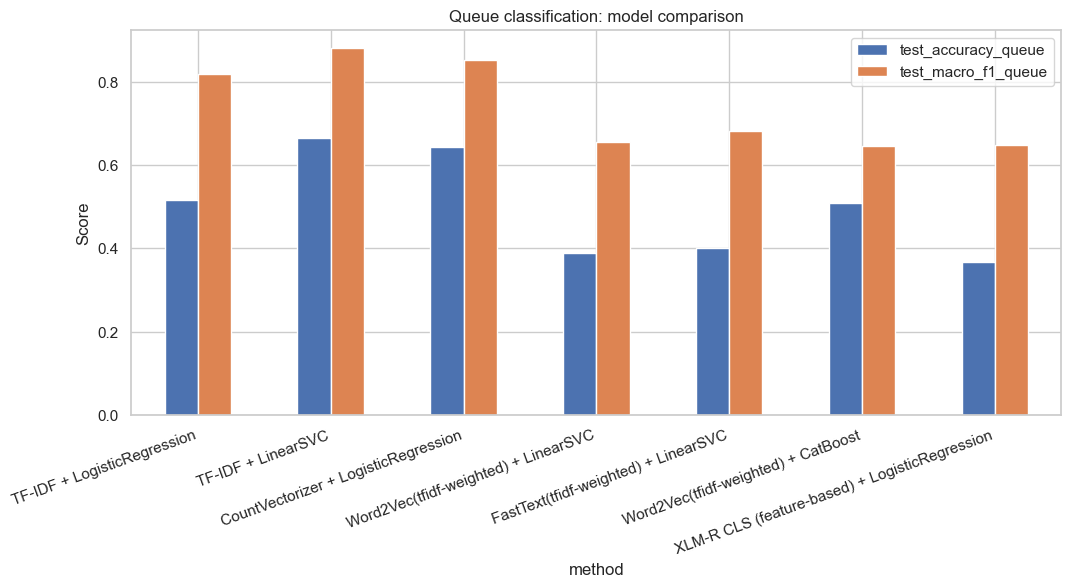

In [100]:
# =========================
# COMPARE ALL METHODS
# =========================

plot_df = results_main.set_index("method")[["test_accuracy_queue", "test_macro_f1_queue"]]
display(plot_df)

plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Queue classification: model comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.show()

## XLM-R mean pooling + normalization + LinearSVC / LogisticRegression grid

In [101]:
# =========================
# FEATURE-BASED XLM-R (TUNED)
# mean pooling instead of CLS
# =========================

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

In [102]:
class TextDataset(Dataset):
    def __init__(self, texts):
        self.texts = list(texts)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx]

In [103]:
MAX_LENGTH = 192
BATCH_SIZE = 32

def collate_batch(batch_texts):
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    return {k: v.to(DEVICE) for k, v in encoded.items()}

In [104]:
# =========================
# MEAN POOLING
# =========================

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    masked_embeddings = last_hidden_state * mask
    summed = masked_embeddings.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

In [105]:
# =========================
# EXTRACT MEAN EMBEDDINGS
# =========================

@torch.no_grad()
def extract_mean_embeddings(texts, batch_size=BATCH_SIZE):
    dataset = TextDataset(texts)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_batch
    )

    all_embeddings = []

    for batch in tqdm(loader, desc="Extracting mean embeddings"):
        outputs = encoder(**batch)
        pooled = mean_pooling(outputs.last_hidden_state, batch["attention_mask"])
        all_embeddings.append(pooled.detach().cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

In [106]:
# =========================
# BUILD MEAN-POOLED EMBEDDINGS
# =========================

X_train_xlmr_mean = extract_mean_embeddings(X_train_text)
X_val_xlmr_mean   = extract_mean_embeddings(X_val_text)
X_test_xlmr_mean  = extract_mean_embeddings(X_test_text)

print("X_train_xlmr_mean:", X_train_xlmr_mean.shape)
print("X_val_xlmr_mean:  ", X_val_xlmr_mean.shape)
print("X_test_xlmr_mean: ", X_test_xlmr_mean.shape)

Extracting mean embeddings:   0%|          | 0/1545 [00:00<?, ?it/s]

Extracting mean embeddings:   0%|          | 0/193 [00:00<?, ?it/s]

Extracting mean embeddings:   0%|          | 0/194 [00:00<?, ?it/s]

X_train_xlmr_mean: (49412, 768)
X_val_xlmr_mean:   (6176, 768)
X_test_xlmr_mean:  (6177, 768)


In [107]:
# =========================
# L2 NORMALIZATION
# =========================

from sklearn.preprocessing import normalize

X_train_xlmr_mean_norm = normalize(X_train_xlmr_mean, norm="l2")
X_val_xlmr_mean_norm   = normalize(X_val_xlmr_mean, norm="l2")
X_test_xlmr_mean_norm  = normalize(X_test_xlmr_mean, norm="l2")

In [108]:
# =========================
# TUNE LINEARSVC
# =========================

from sklearn.svm import LinearSVC

svc_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
svc_results = []

best_svc_model = None
best_svc_score = -1
best_svc_C = None

for C in svc_grid:
    model = LinearSVC(
        C=C,
        class_weight="balanced",
        random_state=SEED
    )
    model.fit(X_train_xlmr_mean_norm, y_train_queue)

    val_pred = model.predict(X_val_xlmr_mean_norm)
    val_metrics = compute_classification_metrics(y_val_queue, val_pred)

    svc_results.append({
        "model": "LinearSVC",
        "C": C,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"]
    })

    print(f"C={C:<4} | val_acc={val_metrics['accuracy']:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f}")

    if val_metrics["macro_f1"] > best_svc_score:
        best_svc_score = val_metrics["macro_f1"]
        best_svc_model = model
        best_svc_C = C

svc_results_df = pd.DataFrame(svc_results).sort_values("val_macro_f1", ascending=False)
display(svc_results_df)
print("Best LinearSVC C:", best_svc_C)

C=0.25 | val_acc=0.2866 | val_macro_f1=0.3077
C=0.5  | val_acc=0.2952 | val_macro_f1=0.3399
C=1.0  | val_acc=0.3075 | val_macro_f1=0.3784
C=2.0  | val_acc=0.3201 | val_macro_f1=0.4159
C=4.0  | val_acc=0.3373 | val_macro_f1=0.4521


,model,C,val_accuracy,val_macro_f1
4,LinearSVC,4.00,0.337273,0.452118
3,LinearSVC,2.00,0.320110,0.415897
2,LinearSVC,1.00,0.307481,0.378414
1,LinearSVC,0.50,0.295175,0.339887
0,LinearSVC,0.25,0.286593,0.307681


Best LinearSVC C: 4.0


In [109]:
# =========================
# TUNE LOGISTIC REGRESSION
# =========================

from sklearn.linear_model import LogisticRegression

lr_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
lr_results = []

best_lr_model = None
best_lr_score = -1
best_lr_C = None

for C in lr_grid:
    model = LogisticRegression(
        C=C,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=1
    )
    model.fit(X_train_xlmr_mean_norm, y_train_queue)

    val_pred = model.predict(X_val_xlmr_mean_norm)
    val_metrics = compute_classification_metrics(y_val_queue, val_pred)

    lr_results.append({
        "model": "LogisticRegression",
        "C": C,
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"]
    })

    print(f"C={C:<4} | val_acc={val_metrics['accuracy']:.4f} | val_macro_f1={val_metrics['macro_f1']:.4f}")

    if val_metrics["macro_f1"] > best_lr_score:
        best_lr_score = val_metrics["macro_f1"]
        best_lr_model = model
        best_lr_C = C

lr_results_df = pd.DataFrame(lr_results).sort_values("val_macro_f1", ascending=False)
display(lr_results_df)
print("Best LogisticRegression C:", best_lr_C)

C=0.25 | val_acc=0.1737 | val_macro_f1=0.1967
C=0.5  | val_acc=0.1758 | val_macro_f1=0.1969
C=1.0  | val_acc=0.1720 | val_macro_f1=0.1972
C=2.0  | val_acc=0.1773 | val_macro_f1=0.1973
C=4.0  | val_acc=0.2126 | val_macro_f1=0.2426


,model,C,val_accuracy,val_macro_f1
4,LogisticRegression,4.00,0.212597,0.242565
3,LogisticRegression,2.00,0.177299,0.197339
2,LogisticRegression,1.00,0.171956,0.197163
1,LogisticRegression,0.50,0.175842,0.196920
0,LogisticRegression,0.25,0.173737,0.196653


Best LogisticRegression C: 4.0


In [110]:
# =========================
# TEST EVALUATION: BEST MODELS
# =========================

best_svc_val_pred = best_svc_model.predict(X_val_xlmr_mean_norm)
best_svc_test_pred = best_svc_model.predict(X_test_xlmr_mean_norm)

best_svc_val_metrics = compute_classification_metrics(y_val_queue, best_svc_val_pred)
best_svc_test_metrics = compute_classification_metrics(y_test_queue, best_svc_test_pred)

print("Tuned XLM-R mean pooling + LinearSVC")
print("-" * 50)
print(f"Validation Accuracy : {best_svc_val_metrics['accuracy']:.4f}")
print(f"Validation Macro-F1 : {best_svc_val_metrics['macro_f1']:.4f}")
print(f"Test Accuracy       : {best_svc_test_metrics['accuracy']:.4f}")
print(f"Test Macro-F1       : {best_svc_test_metrics['macro_f1']:.4f}")
print()

best_lr_val_pred = best_lr_model.predict(X_val_xlmr_mean_norm)
best_lr_test_pred = best_lr_model.predict(X_test_xlmr_mean_norm)

best_lr_val_metrics = compute_classification_metrics(y_val_queue, best_lr_val_pred)
best_lr_test_metrics = compute_classification_metrics(y_test_queue, best_lr_test_pred)

print("Tuned XLM-R mean pooling + LogisticRegression")
print("-" * 50)
print(f"Validation Accuracy : {best_lr_val_metrics['accuracy']:.4f}")
print(f"Validation Macro-F1 : {best_lr_val_metrics['macro_f1']:.4f}")
print(f"Test Accuracy       : {best_lr_test_metrics['accuracy']:.4f}")
print(f"Test Macro-F1       : {best_lr_test_metrics['macro_f1']:.4f}")

Tuned XLM-R mean pooling + LinearSVC
--------------------------------------------------
Validation Accuracy : 0.3373
Validation Macro-F1 : 0.4521
Test Accuracy       : 0.3257
Test Macro-F1       : 0.4343

Tuned XLM-R mean pooling + LogisticRegression
--------------------------------------------------
Validation Accuracy : 0.2126
Validation Macro-F1 : 0.2426
Test Accuracy       : 0.2074
Test Macro-F1       : 0.2365


In [111]:
# =========================
# UPDATE RESULTS TABLE
# =========================

new_rows = [
    {
        "method": f"XLM-R mean pooling + LinearSVC (C={best_svc_C})",
        "val_accuracy_queue": best_svc_val_metrics["accuracy"],
        "val_macro_f1_queue": best_svc_val_metrics["macro_f1"],
        "test_accuracy_queue": best_svc_test_metrics["accuracy"],
        "test_macro_f1_queue": best_svc_test_metrics["macro_f1"],
    },
    {
        "method": f"XLM-R mean pooling + LogisticRegression (C={best_lr_C})",
        "val_accuracy_queue": best_lr_val_metrics["accuracy"],
        "val_macro_f1_queue": best_lr_val_metrics["macro_f1"],
        "test_accuracy_queue": best_lr_test_metrics["accuracy"],
        "test_macro_f1_queue": best_lr_test_metrics["macro_f1"],
    }
]

results_main = pd.concat([results_main, pd.DataFrame(new_rows)], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
3,FastText(tfidf-weighted) + LinearSVC,0.397021,0.684206,0.401651,0.680731
4,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855
5,XLM-R CLS (feature-based) + LogisticRegression,0.371276,0.645865,0.367654,0.647285
6,Word2Vec(tfidf-weighted) + CatBoost,0.499838,0.639526,0.509471,0.644927
7,XLM-R mean pooling + LinearSVC (C=4.0),0.337273,0.452118,0.325724,0.434327
8,XLM-R mean pooling + LogisticRegression (C=4.0),0.212597,0.242565,0.207382,0.236487


,test_accuracy_queue,test_macro_f1_queue
method,,
TF-IDF + LinearSVC,0.663753,0.880546
CountVectorizer + LogisticRegression,0.644488,0.853407
TF-IDF + LogisticRegression,0.516594,0.819194
FastText(tfidf-weighted) + LinearSVC,0.401651,0.680731
Word2Vec(tfidf-weighted) + LinearSVC,0.389509,0.654855
XLM-R CLS (feature-based) + LogisticRegression,0.367654,0.647285
Word2Vec(tfidf-weighted) + CatBoost,0.509471,0.644927
XLM-R mean pooling + LinearSVC (C=4.0),0.325724,0.434327
XLM-R mean pooling + LogisticRegression (C=4.0),0.207382,0.236487


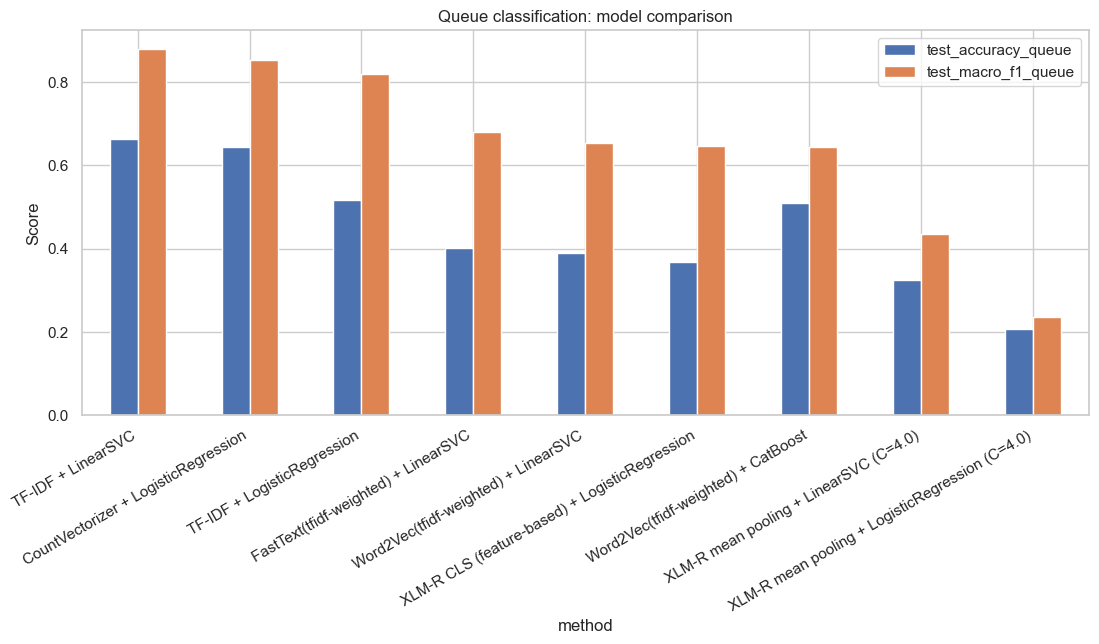

In [112]:
plot_df = results_main.set_index("method")[["test_accuracy_queue", "test_macro_f1_queue"]]
display(plot_df.sort_values("test_macro_f1_queue", ascending=False))

plot_df.sort_values("test_macro_f1_queue", ascending=False).plot(kind="bar", figsize=(13, 5))
plt.title("Queue classification: model comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.show()

## MULTITASK XLM-R FINE-TUNING

In [115]:
# =========================
# MULTITASK XLM-R FINE-TUNING
# =========================

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

In [116]:
# =========================
# SEED
# =========================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [117]:
# =========================
# DEVICE & HYPERPARAMETERS
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "xlm-roberta-base"

MAX_LENGTH = 192
BATCH_SIZE = 8
EPOCHS = 2
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

print("DEVICE:", DEVICE)
print("MODEL_NAME:", MODEL_NAME)

DEVICE: cpu
MODEL_NAME: xlm-roberta-base


In [118]:
# =========================
# LABEL ENCODING
# =========================

queue_le = LabelEncoder()
priority_le = LabelEncoder()
type_le = LabelEncoder()

train_df["queue_id"] = queue_le.fit_transform(train_df["queue"])
val_df["queue_id"]   = queue_le.transform(val_df["queue"])
test_df["queue_id"]  = queue_le.transform(test_df["queue"])

train_df["priority_id"] = priority_le.fit_transform(train_df["priority"])
val_df["priority_id"]   = priority_le.transform(val_df["priority"])
test_df["priority_id"]  = priority_le.transform(test_df["priority"])

train_df["type_id"] = type_le.fit_transform(train_df["type"])
val_df["type_id"]   = type_le.transform(val_df["type"])
test_df["type_id"]  = type_le.transform(test_df["type"])

NUM_QUEUE = len(queue_le.classes_)
NUM_PRIORITY = len(priority_le.classes_)
NUM_TYPE = len(type_le.classes_)

print("NUM_QUEUE:", NUM_QUEUE)
print("NUM_PRIORITY:", NUM_PRIORITY)
print("NUM_TYPE:", NUM_TYPE)

NUM_QUEUE: 52
NUM_PRIORITY: 5
NUM_TYPE: 5


In [119]:
# =========================
# TOKENIZER
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

In [120]:
# =========================
# DATASET
# =========================

class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=192):
        self.texts = df["text"].tolist()
        self.queue_labels = df["queue_id"].tolist()
        self.priority_labels = df["priority_id"].tolist()
        self.type_labels = df["type_id"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        item = {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels_queue": self.queue_labels[idx],
            "labels_priority": self.priority_labels[idx],
            "labels_type": self.type_labels[idx],
        }
        return item

In [121]:
# =========================
# COLLATE FUNCTION
# =========================

def multitask_collate_fn(batch):
    features = [
        {
            "input_ids": x["input_ids"],
            "attention_mask": x["attention_mask"]
        }
        for x in batch
    ]

    padded = collator(features)

    padded["labels_queue"] = torch.tensor([x["labels_queue"] for x in batch], dtype=torch.long)
    padded["labels_priority"] = torch.tensor([x["labels_priority"] for x in batch], dtype=torch.long)
    padded["labels_type"] = torch.tensor([x["labels_type"] for x in batch], dtype=torch.long)

    return padded

In [122]:
# =========================
# DATALOADERS
# =========================

train_dataset = TicketDataset(train_df, tokenizer, max_length=MAX_LENGTH)
val_dataset   = TicketDataset(val_df, tokenizer, max_length=MAX_LENGTH)
test_dataset  = TicketDataset(test_df, tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=multitask_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=multitask_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=multitask_collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 6177
Val batches: 772
Test batches: 773


In [123]:
# =========================
# MULTITASK MODEL
# =========================

class XLMRMultiTaskModel(nn.Module):
    def __init__(self, model_name, num_queue, num_priority, num_type, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.queue_head = nn.Linear(hidden_size, num_queue)
        self.priority_head = nn.Linear(hidden_size, num_priority)
        self.type_head = nn.Linear(hidden_size, num_type)

    def mean_pooling(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        masked = last_hidden_state * mask
        summed = masked.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        pooled = self.dropout(pooled)

        logits_queue = self.queue_head(pooled)
        logits_priority = self.priority_head(pooled)
        logits_type = self.type_head(pooled)

        return {
            "logits_queue": logits_queue,
            "logits_priority": logits_priority,
            "logits_type": logits_type
        }

In [124]:
# =========================
# INIT TRAINING OBJECTS
# =========================

model = XLMRMultiTaskModel(
    model_name=MODEL_NAME,
    num_queue=NUM_QUEUE,
    num_priority=NUM_PRIORITY,
    num_type=NUM_TYPE,
    dropout=0.2
).to(DEVICE)

criterion_queue = nn.CrossEntropyLoss()
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

num_training_steps: 12354
num_warmup_steps: 1235


In [125]:
# =========================
# METRICS
# =========================

def compute_final_score(queue_macro_f1, priority_acc, type_acc):
    return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc

def evaluate_multitask(model, dataloader, device):
    model.eval()

    all_queue_true, all_queue_pred = [], []
    all_priority_true, all_priority_pred = [], []
    all_type_true, all_type_pred = [], []

    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels_queue = batch["labels_queue"].to(device)
            labels_priority = batch["labels_priority"].to(device)
            labels_type = batch["labels_type"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            logits_queue = outputs["logits_queue"]
            logits_priority = outputs["logits_priority"]
            logits_type = outputs["logits_type"]

            loss_queue = criterion_queue(logits_queue, labels_queue)
            loss_priority = criterion_priority(logits_priority, labels_priority)
            loss_type = criterion_type(logits_type, labels_type)

            loss = 0.70 * loss_queue + 0.15 * loss_priority + 0.15 * loss_type
            total_loss += loss.item()

            pred_queue = torch.argmax(logits_queue, dim=1)
            pred_priority = torch.argmax(logits_priority, dim=1)
            pred_type = torch.argmax(logits_type, dim=1)

            all_queue_true.extend(labels_queue.cpu().numpy())
            all_queue_pred.extend(pred_queue.cpu().numpy())

            all_priority_true.extend(labels_priority.cpu().numpy())
            all_priority_pred.extend(pred_priority.cpu().numpy())

            all_type_true.extend(labels_type.cpu().numpy())
            all_type_pred.extend(pred_type.cpu().numpy())

    queue_acc = accuracy_score(all_queue_true, all_queue_pred)
    queue_macro_f1 = f1_score(all_queue_true, all_queue_pred, average="macro")

    priority_acc = accuracy_score(all_priority_true, all_priority_pred)
    type_acc = accuracy_score(all_type_true, all_type_pred)

    score = compute_final_score(queue_macro_f1, priority_acc, type_acc)

    metrics = {
        "loss": total_loss / len(dataloader),
        "queue_accuracy": queue_acc,
        "queue_macro_f1": queue_macro_f1,
        "priority_accuracy": priority_acc,
        "type_accuracy": type_acc,
        "score": score
    }

    return metrics

In [126]:
# =========================
# TRAIN LOOP
# =========================

best_val_score = -1
best_state_dict = None
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        labels_queue = batch["labels_queue"].to(DEVICE)
        labels_priority = batch["labels_priority"].to(DEVICE)
        labels_type = batch["labels_type"].to(DEVICE)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits_queue = outputs["logits_queue"]
        logits_priority = outputs["logits_priority"]
        logits_type = outputs["logits_type"]

        loss_queue = criterion_queue(logits_queue, labels_queue)
        loss_priority = criterion_priority(logits_priority, labels_priority)
        loss_type = criterion_type(logits_type, labels_type)

        loss = 0.70 * loss_queue + 0.15 * loss_priority + 0.15 * loss_type
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        progress_bar.set_postfix(train_loss=running_loss / (progress_bar.n + 1))

    train_loss = running_loss / len(train_loader)

    val_metrics = evaluate_multitask(model, val_loader, DEVICE)

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history.append(epoch_result)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"Train loss            : {train_loss:.4f}")
    print(f"Val loss              : {val_metrics['loss']:.4f}")
    print(f"Val queue accuracy    : {val_metrics['queue_accuracy']:.4f}")
    print(f"Val queue macro-F1    : {val_metrics['queue_macro_f1']:.4f}")
    print(f"Val priority accuracy : {val_metrics['priority_accuracy']:.4f}")
    print(f"Val type accuracy     : {val_metrics['type_accuracy']:.4f}")
    print(f"Val final score       : {val_metrics['score']:.4f}")

    if val_metrics["score"] > best_val_score:
        best_val_score = val_metrics["score"]
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print("Best model updated.")

Epoch 1/2:   0%|          | 0/6177 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/772 [00:00<?, ?it/s]


Epoch 1/2
Train loss            : 1.4985
Val loss              : 1.1359
Val queue accuracy    : 0.5223
Val queue macro-F1    : 0.7547
Val priority accuracy : 0.5198
Val type accuracy     : 0.8400
Val final score       : 0.7322
Best model updated.


Epoch 2/2:   0%|          | 0/6177 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/772 [00:00<?, ?it/s]


Epoch 2/2
Train loss            : 1.0649
Val loss              : 1.0315
Val queue accuracy    : 0.5735
Val queue macro-F1    : 0.8250
Val priority accuracy : 0.5539
Val type accuracy     : 0.8502
Val final score       : 0.7881
Best model updated.


In [127]:
# =========================
# TRAINING HISTORY
# =========================

history_df = pd.DataFrame(history)
display(history_df)

,epoch,train_loss,val_loss,val_queue_accuracy,val_queue_macro_f1,val_priority_accuracy,val_type_accuracy,val_score
0,1,1.498535,1.135922,0.522345,0.754665,0.519754,0.840026,0.732232
1,2,1.064918,1.031459,0.573510,0.825035,0.553918,0.850227,0.788146


In [128]:
# =========================
# LOAD BEST MODEL & TEST EVAL
# =========================

model.load_state_dict(best_state_dict)
model.to(DEVICE)

test_metrics = evaluate_multitask(model, test_loader, DEVICE)

print("Best multitask XLM-R fine-tuning | TEST")
print("-" * 50)
print(f"Test loss              : {test_metrics['loss']:.4f}")
print(f"Test queue accuracy    : {test_metrics['queue_accuracy']:.4f}")
print(f"Test queue macro-F1    : {test_metrics['queue_macro_f1']:.4f}")
print(f"Test priority accuracy : {test_metrics['priority_accuracy']:.4f}")
print(f"Test type accuracy     : {test_metrics['type_accuracy']:.4f}")
print(f"Test final score       : {test_metrics['score']:.4f}")

Evaluating:   0%|          | 0/773 [00:00<?, ?it/s]

Best multitask XLM-R fine-tuning | TEST
--------------------------------------------------
Test loss              : 1.0337
Test queue accuracy    : 0.5658
Test queue macro-F1    : 0.8219
Test priority accuracy : 0.5446
Test type accuracy     : 0.8417
Test final score       : 0.7832


In [129]:
# =========================
# UPDATE RESULTS TABLE
# =========================

results_main = pd.concat([
    results_main,
    pd.DataFrame([
        {
            "method": "XLM-R multitask fine-tuning",
            "val_accuracy_queue": history_df.iloc[history_df["val_score"].argmax()]["val_queue_accuracy"],
            "val_macro_f1_queue": history_df.iloc[history_df["val_score"].argmax()]["val_queue_macro_f1"],
            "test_accuracy_queue": test_metrics["queue_accuracy"],
            "test_macro_f1_queue": test_metrics["queue_macro_f1"],
        }
    ])
], ignore_index=True)

display(
    results_main.sort_values("test_macro_f1_queue", ascending=False).reset_index(drop=True)
)

,method,val_accuracy_queue,val_macro_f1_queue,test_accuracy_queue,test_macro_f1_queue
0,TF-IDF + LinearSVC,0.651554,0.880675,0.663753,0.880546
1,CountVectorizer + LogisticRegression,0.639896,0.857801,0.644488,0.853407
2,XLM-R multitask fine-tuning,0.573510,0.825035,0.565809,0.821863
3,TF-IDF + LogisticRegression,0.511172,0.829838,0.516594,0.819194
4,FastText(tfidf-weighted) + LinearSVC,0.397021,0.684206,0.401651,0.680731
5,Word2Vec(tfidf-weighted) + LinearSVC,0.388763,0.670577,0.389509,0.654855
6,XLM-R CLS (feature-based) + LogisticRegression,0.371276,0.645865,0.367654,0.647285
7,Word2Vec(tfidf-weighted) + CatBoost,0.499838,0.639526,0.509471,0.644927
8,XLM-R mean pooling + LinearSVC (C=4.0),0.337273,0.452118,0.325724,0.434327
9,XLM-R mean pooling + LogisticRegression (C=4.0),0.212597,0.242565,0.207382,0.236487


In [130]:
# =========================
# FULL MULTITASK RESULTS
# =========================

multitask_results = pd.DataFrame([
    {
        "model": "XLM-R multitask fine-tuning",
        "queue_macro_f1": test_metrics["queue_macro_f1"],
        "queue_accuracy": test_metrics["queue_accuracy"],
        "priority_accuracy": test_metrics["priority_accuracy"],
        "type_accuracy": test_metrics["type_accuracy"],
        "final_score": test_metrics["score"],
    }
])

display(multitask_results)

,model,queue_macro_f1,queue_accuracy,priority_accuracy,type_accuracy,final_score
0,XLM-R multitask fine-tuning,0.821863,0.565809,0.544601,0.841671,0.783245


## берем лучшую модель

In [131]:
# =========================
# CONFIDENCE ANALYSIS FOR BEST MODEL
# TF-IDF + LinearSVC
# =========================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

In [132]:
# decision scores on test
test_scores_svc = tfidf_svc_queue.decision_function(X_test_text)
test_pred_svc = tfidf_svc_queue.predict(X_test_text)

print(type(test_scores_svc), test_scores_svc.shape)
print("Predictions:", len(test_pred_svc))

<class 'numpy.ndarray'> (6177, 52)
Predictions: 6177


In [133]:
# =========================
# CONFIDENCE = TOP1 - TOP2 MARGIN
# =========================

def multiclass_margin_confidence(score_matrix):
    """
    score_matrix: shape [n_samples, n_classes]
    returns:
        top1_scores, top2_scores, margins
    """
    sorted_scores = np.sort(score_matrix, axis=1)
    top1 = sorted_scores[:, -1]
    top2 = sorted_scores[:, -2]
    margin = top1 - top2
    return top1, top2, margin

top1_scores, top2_scores, confidence_margin = multiclass_margin_confidence(test_scores_svc)

print("Confidence stats:")
print(pd.Series(confidence_margin).describe())

Confidence stats:
count    6177.000000
mean        0.508945
std         0.599416
min         0.000128
25%         0.090205
50%         0.243079
75%         0.732742
max         4.613302
dtype: float64


In [134]:
# =========================
# TEST CONFIDENCE TABLE
# =========================

confidence_df = test_df.copy().reset_index(drop=True)

confidence_df["y_true_queue"] = y_test_queue
confidence_df["y_pred_queue"] = test_pred_svc
confidence_df["confidence"] = confidence_margin
confidence_df["is_correct"] = (confidence_df["y_true_queue"] == confidence_df["y_pred_queue"]).astype(int)

confidence_df = confidence_df.sort_values("confidence", ascending=False).reset_index(drop=True)

display(confidence_df[["text", "y_true_queue", "y_pred_queue", "confidence", "is_correct"]].head(10))

,text,y_true_queue,y_pred_queue,confidence,is_correct
0,Errors in the Billing System\n\nPayment problems require resolution,Billing and Payments,Billing and Payments,4.613302,1
1,"Anfrage bezüglich der Spamfilter-Einstellungen im Community-Forum\n\nSehr geehrtes Support-Team,\n\nich schreibe Ihnen, um eine Anpassung der Spamfilter-Schwellenwerte für unser Community-Forum zu...",Online Communities/Forums,Online Communities/Forums,3.630736,1
2,Informative Details on Smart Billing\n\nLooking for detailed information on the billing cycles and payment options for the Smart-Wassermelder service. Could you provide me with the available plans...,Billing and Payments,Billing and Payments,3.606790,1
3,Informative Details on Smart Billing\n\nLooking for detailed information on the billing cycles and payment options for the Smart-Wassermelder service. Could you provide me with the available plans...,Billing and Payments,Billing and Payments,3.606790,1
4,"Problem with Billing Invoice Charges\n\nThe marketing agency observed unforeseen charges on their invoice, potentially due to errors in the billing system. They examined prior invoices and reached...",Billing and Payments,Billing and Payments,3.574420,1
5,"Problem with Invoice Billing\n\nThe marketing firm observed unforeseen billing charges on their invoice, potentially due to errors in the billing system. They examined past invoices and reached ou...",Billing and Payments,Billing and Payments,3.559573,1
6,"Probleme beim Herunterladen von Bastelprojektvorlagen von TaskForge Kanban\n\nSupport-Team,\nich habe Probleme beim Zugriff auf die DIY-Muster-Downloads. Könnten Sie mir bitte dabei helfen?",Hobbies & Leisure/Crafts,Hobbies & Leisure/Crafts,3.518766,1
7,Queries Regarding Billing Payment Methods\n\nIs it possible to get details on the available billing options and payment processing for the SaaS project management tool?,Billing and Payments,Billing and Payments,3.497035,1
8,Queries Regarding Billing Payment Methods\n\nIs it possible to get details on the available billing options and payment processing for the SaaS project management tool?,Billing and Payments,Billing and Payments,3.497035,1
9,Incorrect billing summaries impacting payment accuracy\n\nBilling summaries that are inaccurate are impacting the precision of payments.,Billing and Payments,Billing and Payments,3.205218,1


In [135]:
# =========================
# METRICS ON TOP-CONFIDENCE SUBSETS
# =========================

def evaluate_top_confidence_subsets(df, coverages=(1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3)):
    rows = []
    n = len(df)

    for coverage in coverages:
        k = max(1, int(round(n * coverage)))
        sub = df.iloc[:k].copy()

        acc = accuracy_score(sub["y_true_queue"], sub["y_pred_queue"])
        macro_f1 = f1_score(sub["y_true_queue"], sub["y_pred_queue"], average="macro")

        rows.append({
            "coverage": coverage,
            "auto_share": coverage,
            "manual_share": 1.0 - coverage,
            "n_samples": k,
            "accuracy_queue": acc,
            "macro_f1_queue": macro_f1,
            "error_rate": 1.0 - acc,
            "min_confidence_in_subset": sub["confidence"].min(),
        })

    return pd.DataFrame(rows)

coverage_results = evaluate_top_confidence_subsets(confidence_df)
display(coverage_results)

,coverage,auto_share,manual_share,n_samples,accuracy_queue,macro_f1_queue,error_rate,min_confidence_in_subset
0,1.00,1.00,0.00,6177,0.663753,0.880546,0.336247,0.000128
1,0.95,0.95,0.05,5868,0.683708,0.889380,0.316292,0.015791
2,0.90,0.90,0.10,5559,0.706782,0.898271,0.293218,0.032508
3,0.80,0.80,0.20,4942,0.753136,0.915433,0.246864,0.068461
4,0.70,0.70,0.30,4324,0.798335,0.927623,0.201665,0.115113
5,0.60,0.60,0.40,3706,0.851052,0.942086,0.148948,0.169086
6,0.50,0.50,0.50,3088,0.903174,0.959138,0.096826,0.243084
7,0.40,0.40,0.60,2471,0.952246,0.976351,0.047754,0.359671
8,0.30,0.30,0.70,1853,0.983270,0.988157,0.016730,0.548612


In [136]:
# =========================
# PRETTY VIEW
# =========================

coverage_results_pretty = coverage_results.copy()
coverage_results_pretty["coverage_pct"] = (coverage_results_pretty["coverage"] * 100).round(0).astype(int)
coverage_results_pretty["manual_pct"] = (coverage_results_pretty["manual_share"] * 100).round(0).astype(int)

display(
    coverage_results_pretty[
        ["coverage_pct", "manual_pct", "n_samples", "accuracy_queue", "macro_f1_queue", "error_rate"]
    ].sort_values("coverage_pct", ascending=False)
)

,coverage_pct,manual_pct,n_samples,accuracy_queue,macro_f1_queue,error_rate
0,100,0,6177,0.663753,0.880546,0.336247
1,95,5,5868,0.683708,0.889380,0.316292
2,90,10,5559,0.706782,0.898271,0.293218
3,80,20,4942,0.753136,0.915433,0.246864
4,70,30,4324,0.798335,0.927623,0.201665
5,60,40,3706,0.851052,0.942086,0.148948
6,50,50,3088,0.903174,0.959138,0.096826
7,40,60,2471,0.952246,0.976351,0.047754
8,30,70,1853,0.983270,0.988157,0.016730


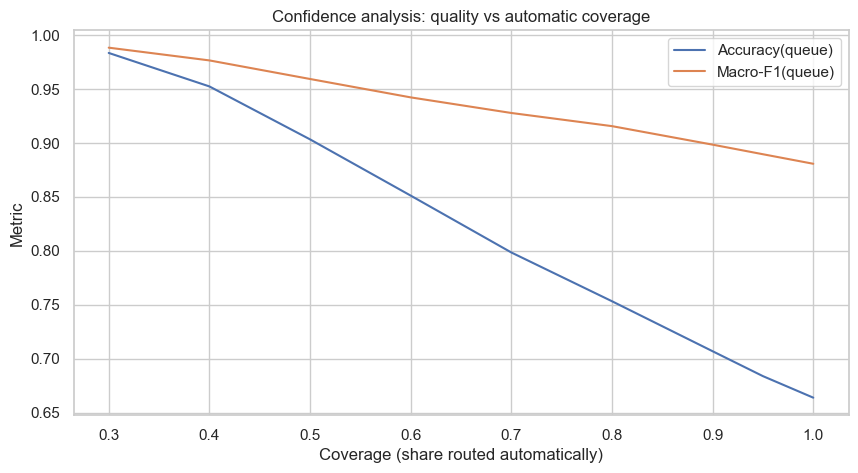

In [137]:
# =========================
# PLOTS: COVERAGE VS QUALITY
# =========================

plot_df = coverage_results.sort_values("coverage")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["coverage"], plot_df["accuracy_queue"], label="Accuracy(queue)")
plt.plot(plot_df["coverage"], plot_df["macro_f1_queue"], label="Macro-F1(queue)")
plt.xlabel("Coverage (share routed automatically)")
plt.ylabel("Metric")
plt.title("Confidence analysis: quality vs automatic coverage")
plt.legend()
plt.show()

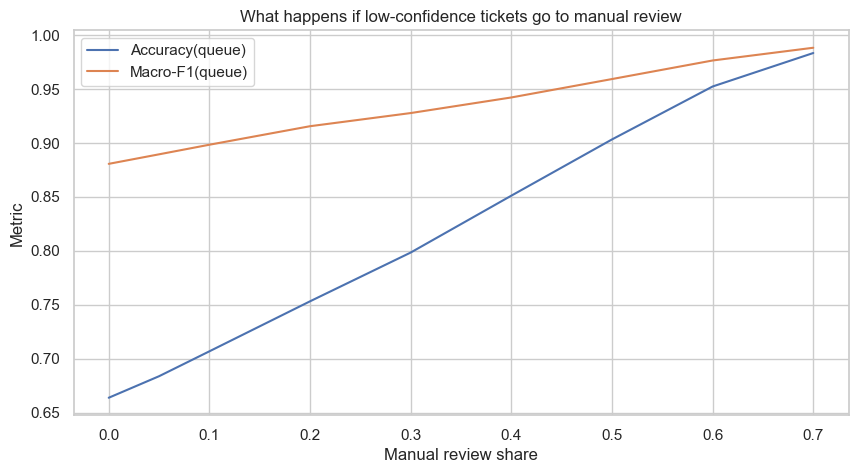

In [138]:
plt.figure(figsize=(10, 5))
plt.plot(plot_df["manual_share"], plot_df["accuracy_queue"], label="Accuracy(queue)")
plt.plot(plot_df["manual_share"], plot_df["macro_f1_queue"], label="Macro-F1(queue)")
plt.xlabel("Manual review share")
plt.ylabel("Metric")
plt.title("What happens if low-confidence tickets go to manual review")
plt.legend()
plt.show()

In [139]:
# =========================
# MANUAL REVIEW SCENARIOS
# =========================

scenario_df = coverage_results.copy()
scenario_df["scenario"] = (
    (scenario_df["auto_share"] * 100).round(0).astype(int).astype(str)
    + "% auto / "
    + (scenario_df["manual_share"] * 100).round(0).astype(int).astype(str)
    + "% manual"
)

display(
    scenario_df[
        ["scenario", "n_samples", "accuracy_queue", "macro_f1_queue", "error_rate"]
    ].sort_values("n_samples", ascending=False)
)

,scenario,n_samples,accuracy_queue,macro_f1_queue,error_rate
0,100% auto / 0% manual,6177,0.663753,0.880546,0.336247
1,95% auto / 5% manual,5868,0.683708,0.889380,0.316292
2,90% auto / 10% manual,5559,0.706782,0.898271,0.293218
3,80% auto / 20% manual,4942,0.753136,0.915433,0.246864
4,70% auto / 30% manual,4324,0.798335,0.927623,0.201665
5,60% auto / 40% manual,3706,0.851052,0.942086,0.148948
6,50% auto / 50% manual,3088,0.903174,0.959138,0.096826
7,40% auto / 60% manual,2471,0.952246,0.976351,0.047754
8,30% auto / 70% manual,1853,0.983270,0.988157,0.016730


In [140]:
# =========================
# MOST / LEAST CONFIDENT EXAMPLES
# =========================

print("Most confident examples:")
display(
    confidence_df[
        ["text", "y_true_queue", "y_pred_queue", "confidence", "is_correct"]
    ].head(10)
)

print("Least confident examples:")
display(
    confidence_df[
        ["text", "y_true_queue", "y_pred_queue", "confidence", "is_correct"]
    ].tail(10)
)

Most confident examples:


,text,y_true_queue,y_pred_queue,confidence,is_correct
0,Errors in the Billing System\n\nPayment problems require resolution,Billing and Payments,Billing and Payments,4.613302,1
1,"Anfrage bezüglich der Spamfilter-Einstellungen im Community-Forum\n\nSehr geehrtes Support-Team,\n\nich schreibe Ihnen, um eine Anpassung der Spamfilter-Schwellenwerte für unser Community-Forum zu...",Online Communities/Forums,Online Communities/Forums,3.630736,1
2,Informative Details on Smart Billing\n\nLooking for detailed information on the billing cycles and payment options for the Smart-Wassermelder service. Could you provide me with the available plans...,Billing and Payments,Billing and Payments,3.606790,1
3,Informative Details on Smart Billing\n\nLooking for detailed information on the billing cycles and payment options for the Smart-Wassermelder service. Could you provide me with the available plans...,Billing and Payments,Billing and Payments,3.606790,1
4,"Problem with Billing Invoice Charges\n\nThe marketing agency observed unforeseen charges on their invoice, potentially due to errors in the billing system. They examined prior invoices and reached...",Billing and Payments,Billing and Payments,3.574420,1
5,"Problem with Invoice Billing\n\nThe marketing firm observed unforeseen billing charges on their invoice, potentially due to errors in the billing system. They examined past invoices and reached ou...",Billing and Payments,Billing and Payments,3.559573,1
6,"Probleme beim Herunterladen von Bastelprojektvorlagen von TaskForge Kanban\n\nSupport-Team,\nich habe Probleme beim Zugriff auf die DIY-Muster-Downloads. Könnten Sie mir bitte dabei helfen?",Hobbies & Leisure/Crafts,Hobbies & Leisure/Crafts,3.518766,1
7,Queries Regarding Billing Payment Methods\n\nIs it possible to get details on the available billing options and payment processing for the SaaS project management tool?,Billing and Payments,Billing and Payments,3.497035,1
8,Queries Regarding Billing Payment Methods\n\nIs it possible to get details on the available billing options and payment processing for the SaaS project management tool?,Billing and Payments,Billing and Payments,3.497035,1
9,Incorrect billing summaries impacting payment accuracy\n\nBilling summaries that are inaccurate are impacting the precision of payments.,Billing and Payments,Billing and Payments,3.205218,1


Least confident examples:


,text,y_true_queue,y_pred_queue,confidence,is_correct
6167,Guidance on Integrating SaaS Solution with Third-Party Hardware\n\nCould you provide details on integrating a SaaS solution with third-party hardware devices? It would be helpful to know the speci...,Customer Service,Service Outages and Maintenance,0.000411,0
6168,"Notification of an Unapproved Access Event\n\nDear Customer Support Team,<br>An unapproved access event has taken place, which might have led to the exposure of medical information. This could be ...",Technical Support,IT Support,0.000396,0
6169,"Security Violation\n\nDear Customer Support Team,\n\nI am submitting a report concerning a severe security vulnerability that has recently impacted the management of several interconnected healthc...",Product Support,IT Support,0.000379,0
6170,"Unterstützung für Analysewerkzeuge in Azure\n\nGeachte Kundenservice, ich mache mich an Sie, um Informationen zu erhalten, die mit Microsoft Azure integrierte Analysewerkzeuge betreffen, welche In...",Sales and Pre-Sales,Sales and Pre-Sales,0.000268,1
6171,Fehlerhafte Funktionsweise der virtuellen Trefferverwaltungsoftware\n\nWährend des Treffers funktionierte die Software nicht richtig.,Technical Support,Shopping/E-commerce,0.000229,0
6172,Seeking Information on Digital Strategy Services\n\nRequesting details,Billing and Payments,Sales and Pre-Sales,0.000226,0
6173,"Software Issues\n\nDear Customer Service, I am writing to report a problem with the Project Management features of our software. There has been a software failure, which may have been caused by re...",Technical Support,Customer Service,0.000217,0
6174,"Software Issues\n\nDear Customer Service, I am writing to report a problem with the Project Management features of our software. There has been a software failure, which may have been caused by re...",Technical Support,Customer Service,0.000217,0
6175,Support Problem with SaaS Platform\n\nUsers are facing repeated disconnections and sluggish responses when accessing the SaaS platform from various devices. There may be conflicts with network ada...,Technical Support,Customer Service,0.000156,0
6176,"Firebase SAP Integration\n\nSehr geehrter Kundenservice, ich bitte um ausführliche Integrationsrichtlinien für die Nutzung der SaaS-Plattform Firebase mit SAP ERP-Systemen. Es wäre hilfreich, wenn...",Customer Service,Billing and Payments,0.000128,0


In [141]:
# =========================
# CONFIDENCE BY LANGUAGE
# =========================

lang_conf_summary = (
    confidence_df.groupby("language")
    .agg(
        n=("language", "size"),
        accuracy_queue=("is_correct", "mean"),
        mean_confidence=("confidence", "mean"),
        median_confidence=("confidence", "median")
    )
    .reset_index()
)

display(lang_conf_summary)

,language,n,accuracy_queue,mean_confidence,median_confidence
0,de,3330,0.665165,0.595333,0.290881
1,en,2847,0.662100,0.407902,0.212485


In [142]:
# =========================
# COVERAGE ANALYSIS BY LANGUAGE
# =========================

coverage_by_lang = []

for lang in sorted(confidence_df["language"].dropna().unique()):
    lang_df = confidence_df[confidence_df["language"] == lang].sort_values("confidence", ascending=False).reset_index(drop=True)
    lang_cov = evaluate_top_confidence_subsets(lang_df)
    lang_cov["language"] = lang
    coverage_by_lang.append(lang_cov)

coverage_by_lang = pd.concat(coverage_by_lang, ignore_index=True)
display(coverage_by_lang.head())

,coverage,auto_share,manual_share,n_samples,accuracy_queue,macro_f1_queue,error_rate,min_confidence_in_subset,language
0,1.00,1.00,0.00,3330,0.665165,0.855697,0.334835,0.000128,de
1,0.95,0.95,0.05,3164,0.686789,0.863924,0.313211,0.014307,de
2,0.90,0.90,0.10,2997,0.712713,0.873088,0.287287,0.032173,de
3,0.80,0.80,0.20,2664,0.766517,0.888762,0.233483,0.068603,de
4,0.70,0.70,0.30,2331,0.820678,0.902167,0.179322,0.117807,de


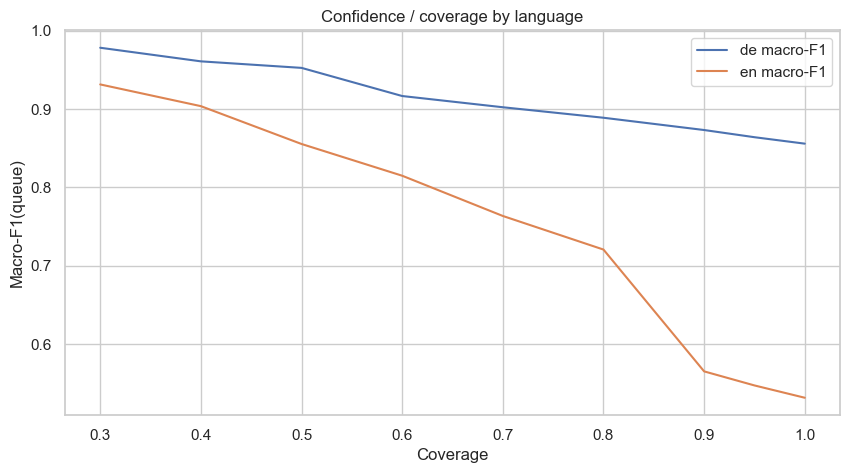

In [143]:
plt.figure(figsize=(10, 5))

for lang in sorted(coverage_by_lang["language"].unique()):
    sub = coverage_by_lang[coverage_by_lang["language"] == lang].sort_values("coverage")
    plt.plot(sub["coverage"], sub["macro_f1_queue"], label=f"{lang} macro-F1")

plt.xlabel("Coverage")
plt.ylabel("Macro-F1(queue)")
plt.title("Confidence / coverage by language")
plt.legend()
plt.show()

## берем лучшую стратегию и получаем целевую метрику по ней

In [144]:
# =========================
# TF-IDF + LinearSVC FOR PRIORITY
# =========================

y_train_priority = train_df["priority"].values
y_val_priority   = val_df["priority"].values
y_test_priority  = test_df["priority"].values

tfidf_svc_priority = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.98,
            ngram_range=(1, 2),
            max_features=200_000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

tfidf_svc_priority.fit(X_train_text, y_train_priority)

val_pred_priority = tfidf_svc_priority.predict(X_val_text)
test_pred_priority = tfidf_svc_priority.predict(X_test_text)

val_acc_priority = accuracy_score(y_val_priority, val_pred_priority)
test_acc_priority = accuracy_score(y_test_priority, test_pred_priority)

print("Priority")
print(f"Val accuracy  : {val_acc_priority:.4f}")
print(f"Test accuracy : {test_acc_priority:.4f}")

Priority
Val accuracy  : 0.7170
Test accuracy : 0.7076


In [145]:
# =========================
# TF-IDF + LinearSVC FOR TYPE
# =========================

y_train_type = train_df["type"].values
y_val_type   = val_df["type"].values
y_test_type  = test_df["type"].values

tfidf_svc_type = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            min_df=2,
            max_df=0.98,
            ngram_range=(1, 2),
            max_features=200_000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=SEED
        )
    )
])

tfidf_svc_type.fit(X_train_text, y_train_type)

val_pred_type = tfidf_svc_type.predict(X_val_text)
test_pred_type = tfidf_svc_type.predict(X_test_text)

val_acc_type = accuracy_score(y_val_type, val_pred_type)
test_acc_type = accuracy_score(y_test_type, test_pred_type)

print("Type")
print(f"Val accuracy  : {val_acc_type:.4f}")
print(f"Test accuracy : {test_acc_type:.4f}")

Type
Val accuracy  : 0.8926
Test accuracy : 0.8977


In [146]:
# =========================
# FULL SCORE FOR TF-IDF + LinearSVC
# =========================

queue_macro_f1_test = test_metrics_queue_svc["macro_f1"]
queue_acc_test = test_metrics_queue_svc["accuracy"]

final_score_tfidf_svc = (
    0.70 * queue_macro_f1_test
    + 0.15 * test_acc_priority
    + 0.15 * test_acc_type
)

print("TF-IDF + LinearSVC | FULL TEST METRICS")
print("-" * 50)
print(f"Queue Macro-F1    : {queue_macro_f1_test:.4f}")
print(f"Queue Accuracy    : {queue_acc_test:.4f}")
print(f"Priority Accuracy : {test_acc_priority:.4f}")
print(f"Type Accuracy     : {test_acc_type:.4f}")
print(f"Final Score       : {final_score_tfidf_svc:.4f}")

TF-IDF + LinearSVC | FULL TEST METRICS
--------------------------------------------------
Queue Macro-F1    : 0.8805
Queue Accuracy    : 0.6638
Priority Accuracy : 0.7076
Type Accuracy     : 0.8977
Final Score       : 0.8572


In [147]:
# =========================
# FINAL SCORE TABLE
# =========================

final_score_rows = []

# classical best model
final_score_rows.append({
    "method": "TF-IDF + LinearSVC (3 separate models)",
    "queue_macro_f1": queue_macro_f1_test,
    "queue_accuracy": queue_acc_test,
    "priority_accuracy": test_acc_priority,
    "type_accuracy": test_acc_type,
    "final_score": final_score_tfidf_svc
})

# multitask model
final_score_rows.append({
    "method": "XLM-R multitask fine-tuning",
    "queue_macro_f1": test_metrics["queue_macro_f1"],
    "queue_accuracy": test_metrics["queue_accuracy"],
    "priority_accuracy": test_metrics["priority_accuracy"],
    "type_accuracy": test_metrics["type_accuracy"],
    "final_score": test_metrics["score"]
})

final_scores_df = pd.DataFrame(final_score_rows)
display(final_scores_df.sort_values("final_score", ascending=False).reset_index(drop=True))

,method,queue_macro_f1,queue_accuracy,priority_accuracy,type_accuracy,final_score
0,TF-IDF + LinearSVC (3 separate models),0.880546,0.663753,0.707625,0.897685,0.857179
1,XLM-R multitask fine-tuning,0.821863,0.565809,0.544601,0.841671,0.783245


### Сравнение моделей для основной задачи `queue`

Были протестированы несколько подходов:

- `CountVectorizer + LogisticRegression`
- `TF-IDF + LogisticRegression`
- `TF-IDF + LinearSVC`
- `Word2Vec + LinearSVC`
- `FastText + LinearSVC`
- `Word2Vec + CatBoost`
- `XLM-RoBERTa` как извлекатель признаков
- `XLM-RoBERTa` с мультитаск fine-tuning

Лучший результат на задаче `queue` показала классическая модель:

**TF-IDF + LinearSVC**
- Test Accuracy: **0.6638**
- Test Macro-F1: **0.8805**

Это оказался лучший результат среди всех протестированных методов.  
Интересно, что классический линейный метод на разреженных TF-IDF признаках заметно превзошёл как эмбеддинговые подходы, так и трансформерные признаки без полноценного дообучения.

--------------------------------
Качество по дополнительным задачам `priority` и `type`

Для итоговой стратегии были обучены отдельные модели `TF-IDF + LinearSVC` для задач `priority` и `type`.

Результаты на test:

- `priority` accuracy: **0.7076**
- `type` accuracy: **0.8977**

Таким образом, задача определения `type` оказалась наиболее простой, а `priority` — заметно сложнее, но всё равно решаемой на хорошем уровне.

--------------------------------

Итоговая метрика

Согласно постановке, итоговый скор вычислялся как:

\[
0.70 \cdot MacroF1(queue) + 0.15 \cdot Accuracy(priority) + 0.15 \cdot Accuracy(type)
\]

Для лучшей стратегии:

**TF-IDF + LinearSVC (3 отдельные модели)**  
- Queue Macro-F1: **0.8805**
- Queue Accuracy: **0.6638**
- Priority Accuracy: **0.7076**
- Type Accuracy: **0.8977**
- **Final Score: 0.8572**

Для сравнения, мультитаск fine-tuning `XLM-R` показал:

- Queue Macro-F1: **0.8219**
- Queue Accuracy: **0.5658**
- Priority Accuracy: **0.5446**
- Type Accuracy: **0.8417**
- **Final Score: 0.7832**

Следовательно, **лучшей итоговой моделью в данной работе стала TF-IDF + LinearSVC**, а не трансформерная мультитаск-модель.

--------------------------------

Интерпретация результатов

Полученные результаты показывают, что для данного датасета ключевую роль играют **лексические маркеры и устойчивые формулировки**, которые очень хорошо улавливаются TF-IDF представлением.  
Особенно хорошо модель распознаёт узкие и тематически специфичные очереди, где встречаются характерные термины.

Основные ошибки приходятся на более широкие и пересекающиеся классы, например:

- `Technical Support`
- `Customer Service`
- `Product Support`
- `Sales and Pre-Sales`
- `General Inquiry`

Именно эти классы семантически ближе друг к другу, поэтому границы между ними размыты, что снижает accuracy.

--------------------------------

Анализ уверенности модели

Для лучшей модели был проведён дополнительный **confidence analysis** на основе разницы между лучшим и вторым по величине score (`top1 - top2`).

Результат показал, что модель можно использовать не только для полной автоматической маршрутизации, но и в режиме **частичной автоматизации**:

- при **100% авто-маршрутизации**:  
  - Accuracy = **0.6638**
  - Macro-F1 = **0.8805**

- при отправке **20% наименее уверенных тикетов на ручную обработку**:  
  - Accuracy = **0.7531**
  - Macro-F1 = **0.9154**

- при отправке **40% наименее уверенных тикетов на ручную обработку**:  
  - Accuracy = **0.8511**
  - Macro-F1 = **0.9421**

- при автообработке только **30% самых уверенных тикетов**:  
  - Accuracy = **0.9833**
  - Macro-F1 = **0.9882**

Это означает, что модель особенно полезна в гибридном сценарии:  
**уверенные случаи можно маршрутизировать автоматически, а спорные — передавать оператору**.

--------------------------------
Общий итог

В работе были выполнены все ключевые этапы решения задачи:

- загрузка и применение фиксированного разбиения;
- предобработка текстов;
- разведочный анализ данных;
- обучение и сравнение нескольких семейств моделей;
- решение всех трёх задач (`queue`, `priority`, `type`);
- расчёт итоговой метрики;
- дополнительный анализ уверенности предсказаний.

Главный практический вывод состоит в том, что **простая линейная модель на TF-IDF признаках оказалась наиболее эффективной** для данного датасета и обеспечила лучший итоговый результат: **Final Score = 0.8572**.  
Это делает её сильным и интерпретируемым baseline-решением для автоматической маршрутизации тикетов.

